In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

# import libraries:
import sys, os
#os.environ['TF_USE_LEGACY_KERAS'] = '1'  # needed for tensorflow KERAS compatibility
os.environ['DISPLAY'] = 'inline'  # hack to get getdist working
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../..')))
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
import getdist
getdist.chains.print_load_details = False
import scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# tensorflow imports:
import tensorflow as tf
import tensorflow_probability as tfp

# import the tensiometer tools that we need:
import tensiometer
from tensiometer.utilities import stats_utilities as utilities
from tensiometer.synthetic_probability import synthetic_probability as sp

# getdist settings to ensure consistency of plots:
getdist_settings = {'ignore_rows': 0.3, 
                    'smooth_scale_2D': 0.5,
                    'smooth_scale_1D': 0.5,
                    }    

2025-07-17 07:25:58.604279: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-17 07:25:58.846970: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-17 07:25:58.847158: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-17 07:25:58.898153: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-17 07:25:59.007990: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-17 07:25:59.009565: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
# ADD MY CHAINS:
# Loading samples
#PLANCK_ALL
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/planck_all', '1_lcdm_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/all_planck', '1_w0wa_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all', '1_EXP_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)

#EFT_cos:
chain_cos = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_cosine/lcdm_eft_cos/planck_all', '1_COS_planck_desidr2_des')
samples_cos = getdist.mcsamples.loadMCSamples(file_root=chain_cos, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_cos = [param.name for param in samples_cos.paramNames.names]
print(param_names_cos)

['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']
['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8'

In [3]:
'''
kwargs = {
          'feedback': 2,
          'plot_every': 1000,
          'pop_size': 1,
          #'cache_dir': 'test',  # set this to a directory to cache the results
          #'root_name': 'test',  # sets the name of the flow for the cache files
        }

flow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain
                          **kwargs)

flow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain
                          **kwargs)

flow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain
                          **kwargs)
'''

"\nkwargs = {\n          'feedback': 2,\n          'plot_every': 1000,\n          'pop_size': 1,\n          #'cache_dir': 'test',  # set this to a directory to cache the results\n          #'root_name': 'test',  # sets the name of the flow for the cache files\n        }\n\nflow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain\n                          **kwargs)\n\nflow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain\n                          **kwargs)\n\nflow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain\n                          **kwargs)\n"

In [4]:
'''
# we can plot training summaries to make sure training went smoothly:
flow_lcdm.training_plot()

flow_w0wa.training_plot()

flow_exp.training_plot()
'''

'\n# we can plot training summaries to make sure training went smoothly:\nflow_lcdm.training_plot()\n\nflow_w0wa.training_plot()\n\nflow_exp.training_plot()\n'

In [5]:
'''
# and we can print the training summary:
flow_lcdm.print_training_summary()

flow_w0wa.print_training_summary()

flow_exp.print_training_summary()
'''

'\n# and we can print the training summary:\nflow_lcdm.print_training_summary()\n\nflow_w0wa.print_training_summary()\n\nflow_exp.print_training_summary()\n'

In [6]:
'''
# we can triangle plot the flow to see how well it has learned the target distribution:
g_lcdm = plots.get_subplot_plotter()
g_lcdm.triangle_plot([samples_lcdm, flow_lcdm.MCSamples(20000)], 
                params=flow_lcdm.param_names,
                filled=True)

g_w0wa = plots.get_subplot_plotter()
g_w0wa.triangle_plot([samples_w0wa, flow_w0wa.MCSamples(20000)], 
                params=flow_w0wa.param_names,
                filled=True)

g_exp = plots.get_subplot_plotter()
g_exp.triangle_plot([samples_exp, flow_exp.MCSamples(20000)], 
                params=flow_exp.param_names,
                filled=True)
'''

'\n# we can triangle plot the flow to see how well it has learned the target distribution:\ng_lcdm = plots.get_subplot_plotter()\ng_lcdm.triangle_plot([samples_lcdm, flow_lcdm.MCSamples(20000)], \n                params=flow_lcdm.param_names,\n                filled=True)\n\ng_w0wa = plots.get_subplot_plotter()\ng_w0wa.triangle_plot([samples_w0wa, flow_w0wa.MCSamples(20000)], \n                params=flow_w0wa.param_names,\n                filled=True)\n\ng_exp = plots.get_subplot_plotter()\ng_exp.triangle_plot([samples_exp, flow_exp.MCSamples(20000)], \n                params=flow_exp.param_names,\n                filled=True)\n'

Re-do:

In [7]:
'''
# this looks nice but not perfect, let's train for longer:
flow_lcdm.feedback = 1
flow_lcdm.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar

flow_w0wa.feedback = 1
flow_w0wa.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar

flow_exp.feedback = 1
flow_exp.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar
'''

"\n# this looks nice but not perfect, let's train for longer:\nflow_lcdm.feedback = 1\nflow_lcdm.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n\nflow_w0wa.feedback = 1\nflow_w0wa.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n\nflow_exp.feedback = 1\nflow_exp.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n"

In [8]:
# we can plot training summaries to make sure training went smoothly:
#flow_lcdm.training_plot()

In [9]:
#flow_w0wa.training_plot()

In [10]:
#flow_exp.training_plot()

In [11]:
'''
# we can triangle plot the flow to see how well it has learned the target distribution:
g_lcdm = plots.get_subplot_plotter()
g_lcdm.triangle_plot([samples_lcdm, 
                 flow_lcdm.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_lcdm.param_names,
                filled=True)
                

g_w0wa = plots.get_subplot_plotter()
g_w0wa.triangle_plot([samples_w0wa, 
                 flow_w0wa.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_w0wa.param_names,
                filled=True)

g_exp = plots.get_subplot_plotter()
g_exp.triangle_plot([samples_exp, 
                 flow_exp.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_exp.param_names,
                filled=True)
'''

'\n# we can triangle plot the flow to see how well it has learned the target distribution:\ng_lcdm = plots.get_subplot_plotter()\ng_lcdm.triangle_plot([samples_lcdm, \n                 flow_lcdm.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_lcdm.param_names,\n                filled=True)\n\n\ng_w0wa = plots.get_subplot_plotter()\ng_w0wa.triangle_plot([samples_w0wa, \n                 flow_w0wa.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_w0wa.param_names,\n                filled=True)\n\ng_exp = plots.get_subplot_plotter()\ng_exp.triangle_plot([samples_exp, \n                 flow_exp.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_exp.param_names,\n                filled=True)\n'

This is now much better

In [12]:
'''
ev_lcdm, eer_lcdm = flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')
'''

"\nev_lcdm, eer_lcdm = flow_lcdm.evidence(weighted=True)\nprint(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')\n\nev_w0wa, eer_w0wa = flow_w0wa.evidence(weighted=True)\nprint(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')\n\nev_exp, eer_exp = flow_exp.evidence(weighted=True)\nprint(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')\n"

# FARLO CON AVERAGE 

In [13]:
kwargs = {
          'feedback': 1,
          'verbose': -1,
          'plot_every': 1000,
          'pop_size': 1,
          'num_flows': 2,
          'epochs': 50,
          #'loss_mode': 'softadapt'
        }



In [14]:
#write ion columns the parameter
#param_names_flow_lcdm = ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'A', 'As', 'H0', 'omegam', 'omegamh2', 'sigma8']
param_names_flow_lcdm = ['logA',
                         'ns', 
                        'ombh2', 
                        'omch2', 
                        'tau', 
                        #'A', 
                        #'As', 
                        'H0', 
                        'omegam', 
                        #'omegamh2', 
                        'sigma8']

average_flow_lcdm = sp.average_flow_from_chain(samples_lcdm, param_names = param_names_flow_lcdm, 
                                               **kwargs)

Training flow 0


/home/andrewcats/anaconda3/envs/tensiometer_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [00:35<00:00,  1.39epoch/s, loss=2.74, val_loss=2.71, lr=0.001]


Training flow 1


100%|██████████| 50/50 [00:34<00:00,  1.44epoch/s, loss=5.33, val_loss=5.25, lr=0.001]


In [15]:
param_names_flow_w0wa = ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'omegam', 'sigma8'] # w wa
average_flow_w0wa = sp.average_flow_from_chain(samples_w0wa, param_names = param_names_flow_w0wa, **kwargs)

Training flow 0


100%|██████████| 50/50 [00:38<00:00,  1.30epoch/s, loss=7.17, val_loss=7.15, lr=0.001]


Training flow 1


100%|██████████| 50/50 [00:32<00:00,  1.52epoch/s, loss=7.02, val_loss=7, lr=0.001]   


In [16]:
param_names_flow_exp = ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'EFT_lambda', 'H0', 'omegam', 'sigma8']
average_flow_exp = sp.average_flow_from_chain(samples_exp, param_names = param_names_flow_exp, **kwargs)

Training flow 0


100%|██████████| 50/50 [00:30<00:00,  1.62epoch/s, loss=7.82, val_loss=7.98, lr=0.001]


Training flow 1


100%|██████████| 50/50 [00:30<00:00,  1.63epoch/s, loss=8.4, val_loss=8.42, lr=0.001] 


In [17]:
param_names_flow_cos = ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'm', 'H0', 'omegam', 'sigma8']
average_flow_cos = sp.average_flow_from_chain(samples_cos, param_names = param_names_flow_cos, **kwargs)

Training flow 0


100%|██████████| 50/50 [00:30<00:00,  1.63epoch/s, loss=8.67, val_loss=8.49, lr=0.001]


Training flow 1


100%|██████████| 50/50 [00:30<00:00,  1.66epoch/s, loss=8.95, val_loss=8.83, lr=0.001]


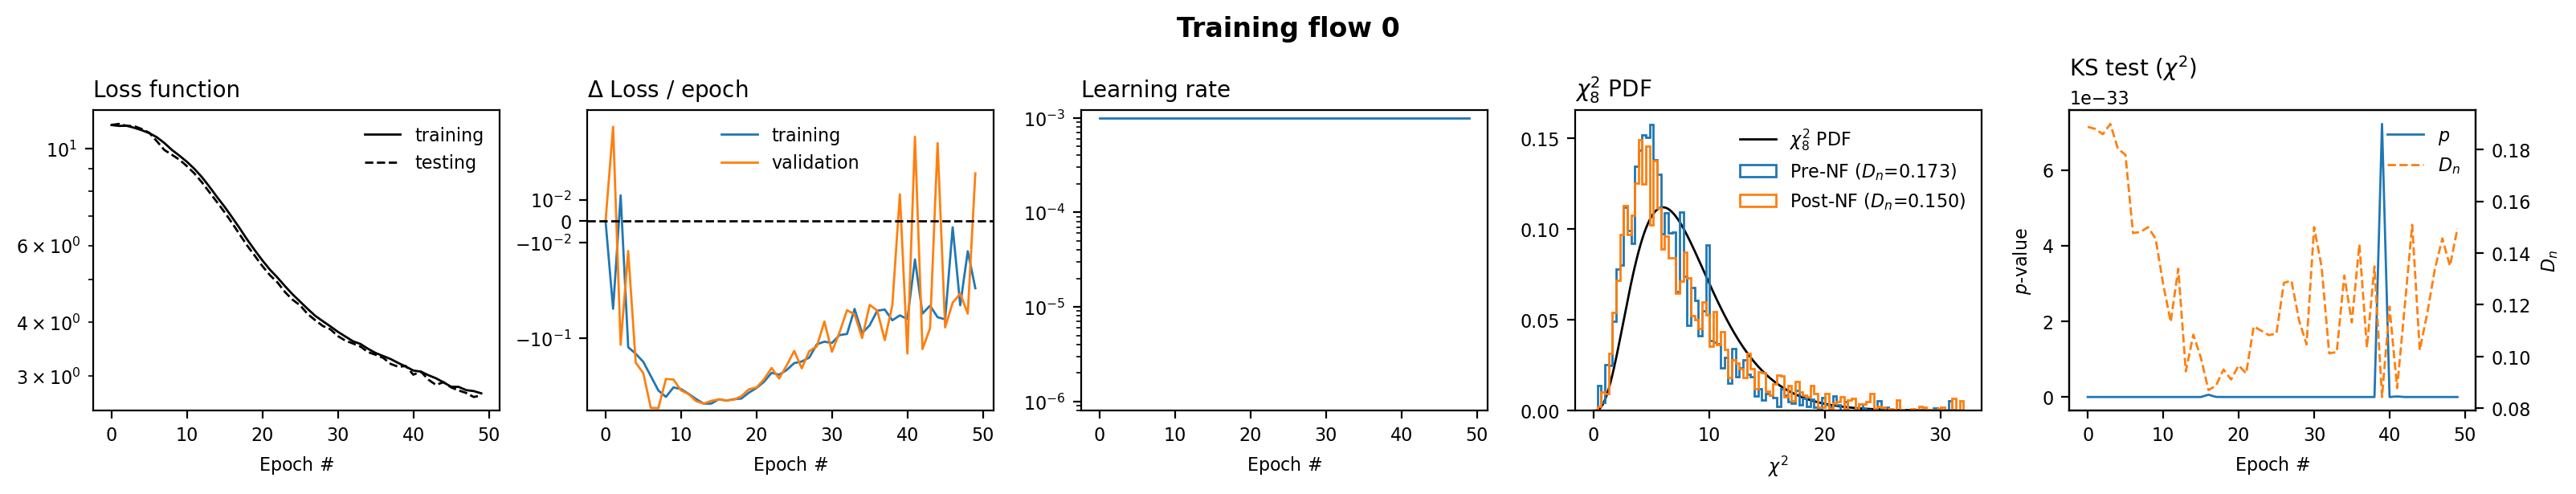

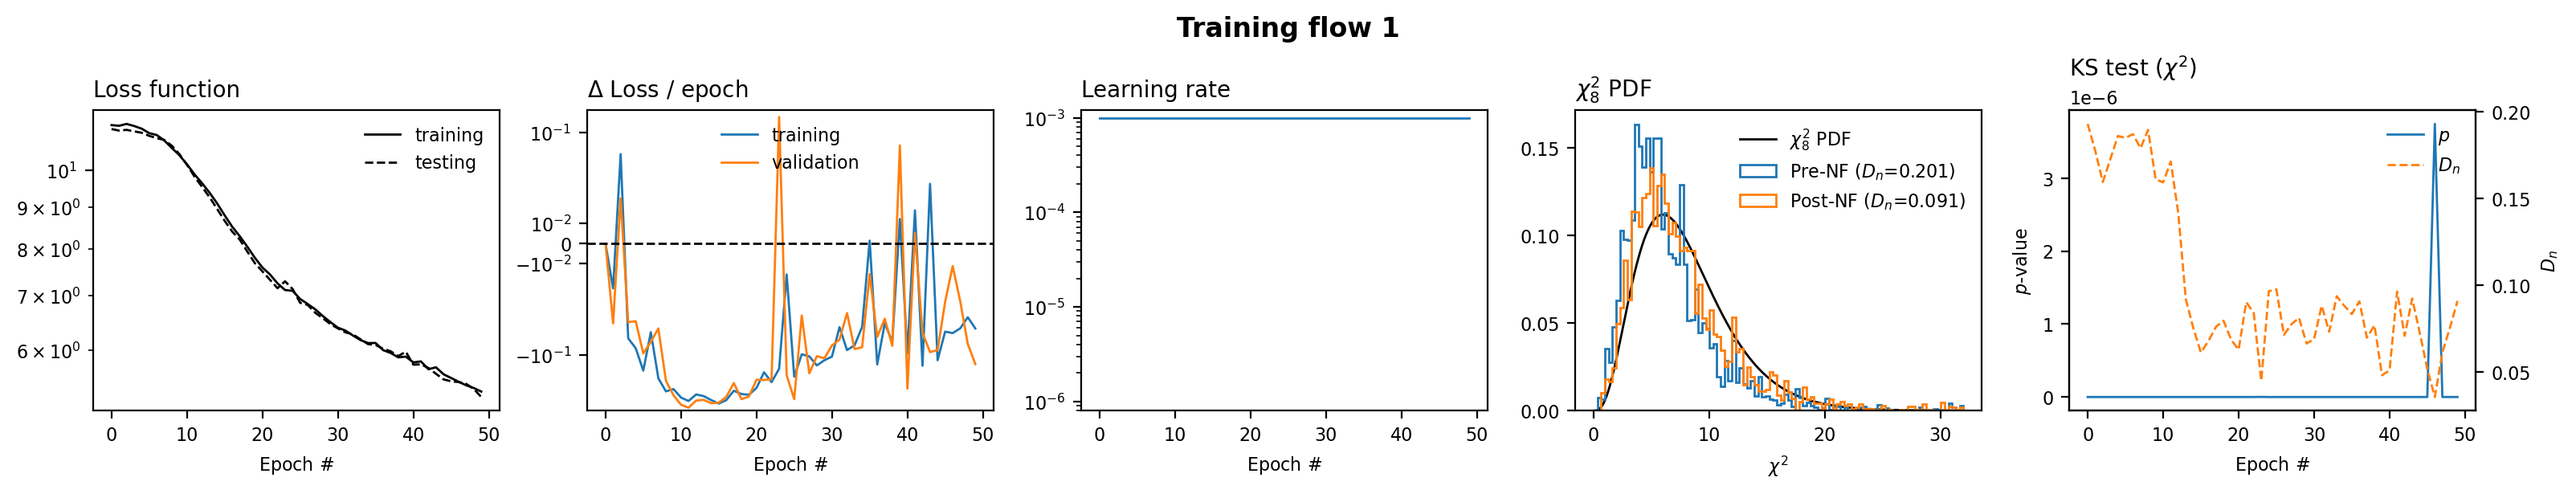

In [18]:
# most methods are implemented for the average flow as well:
average_flow_lcdm.training_plot()

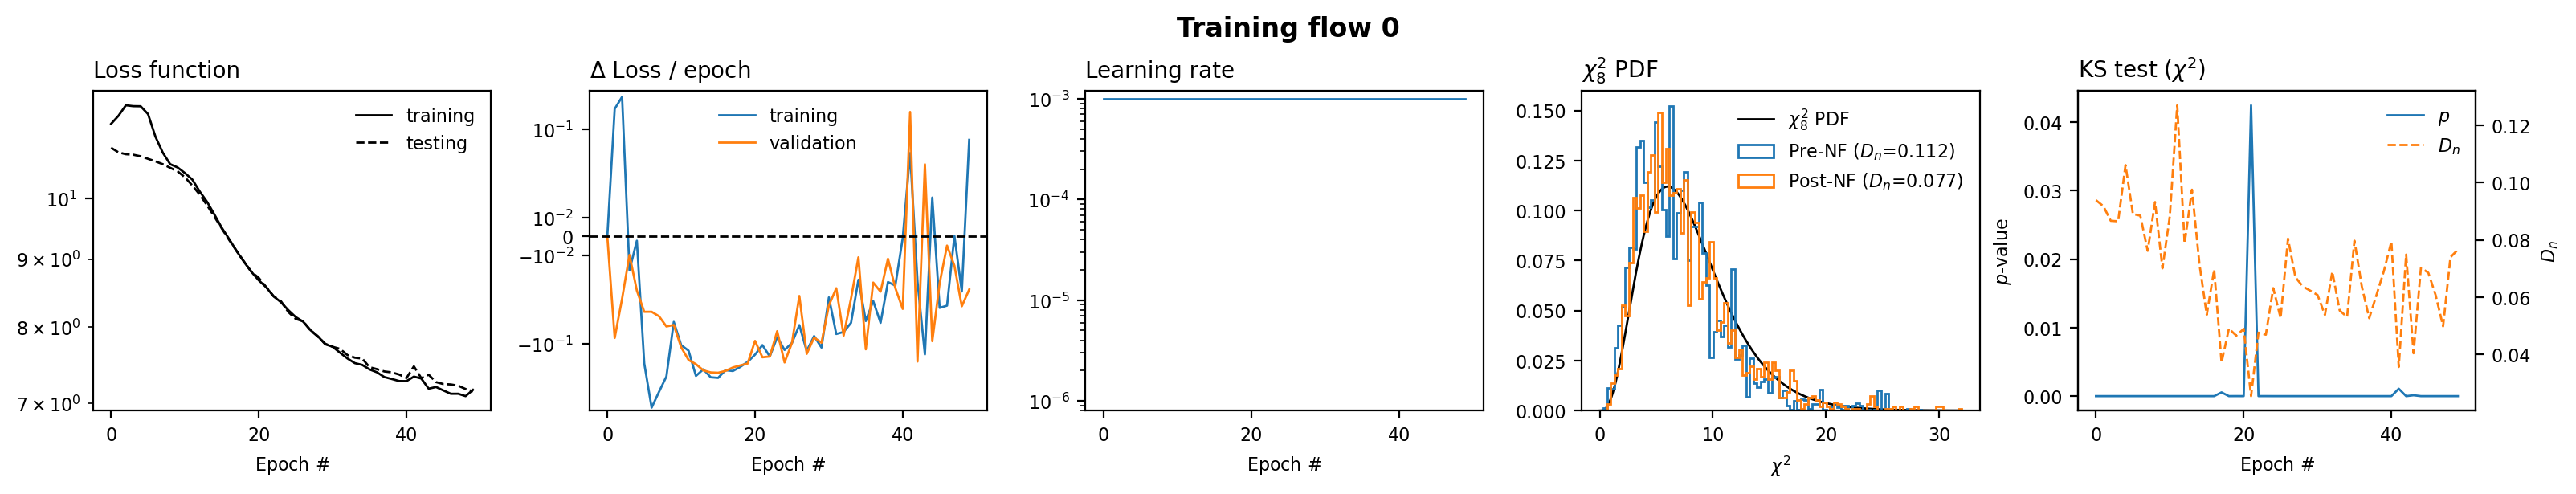

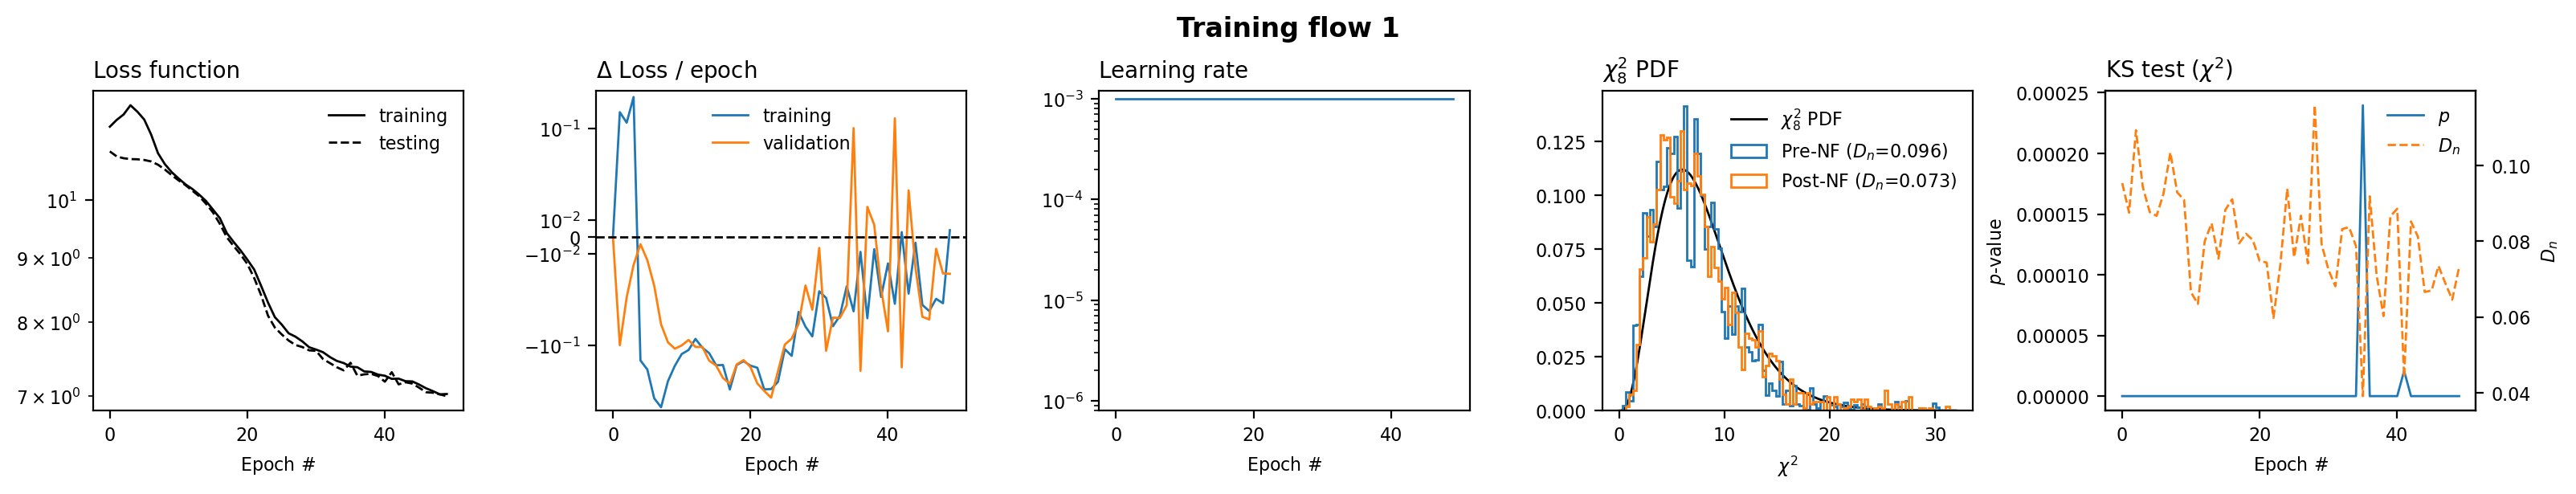

In [19]:
# most methods are implemented for the average flow as well:
average_flow_w0wa.training_plot()

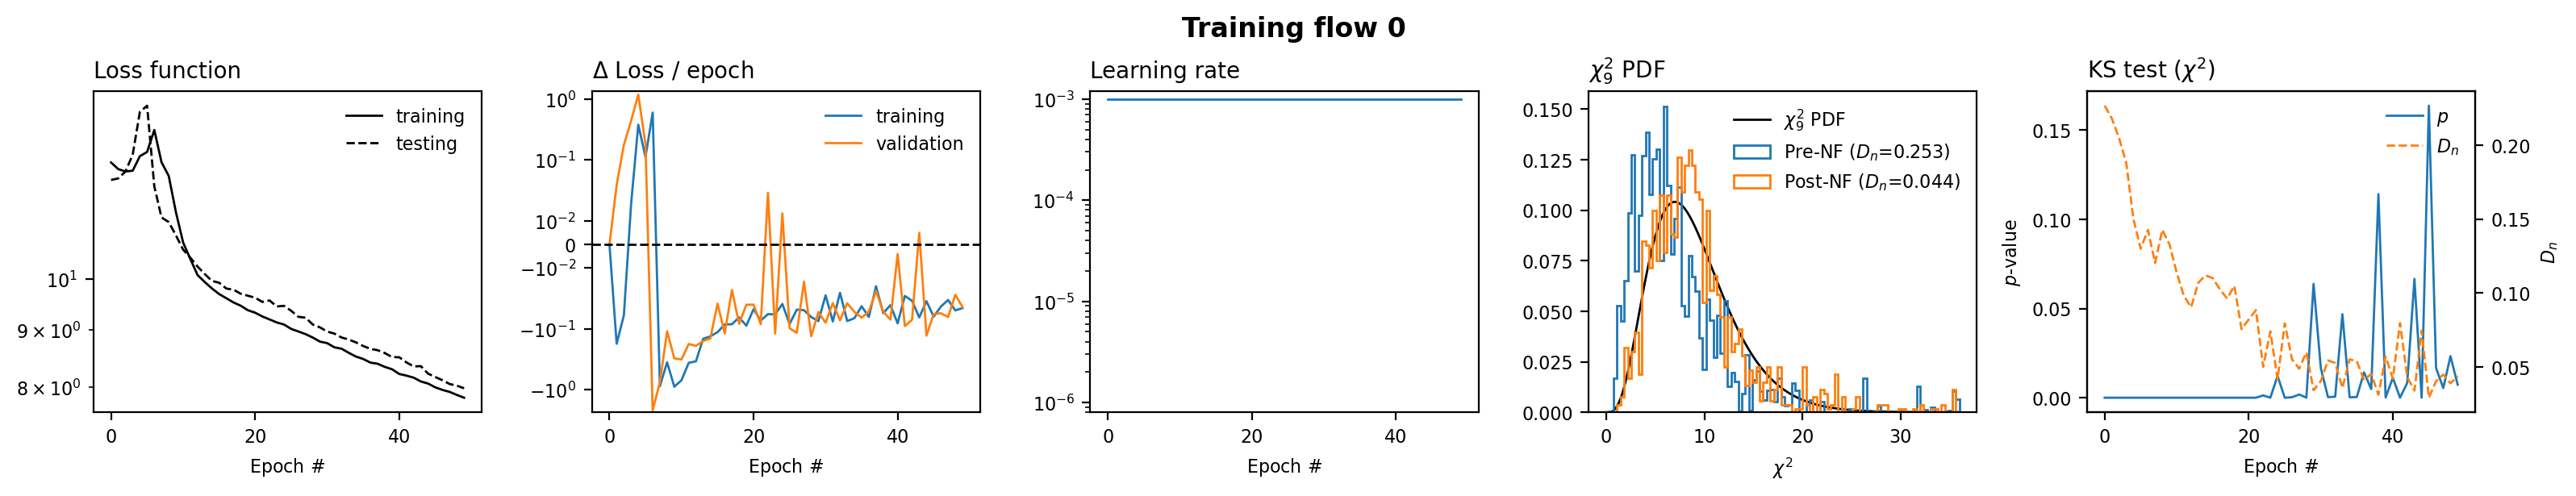

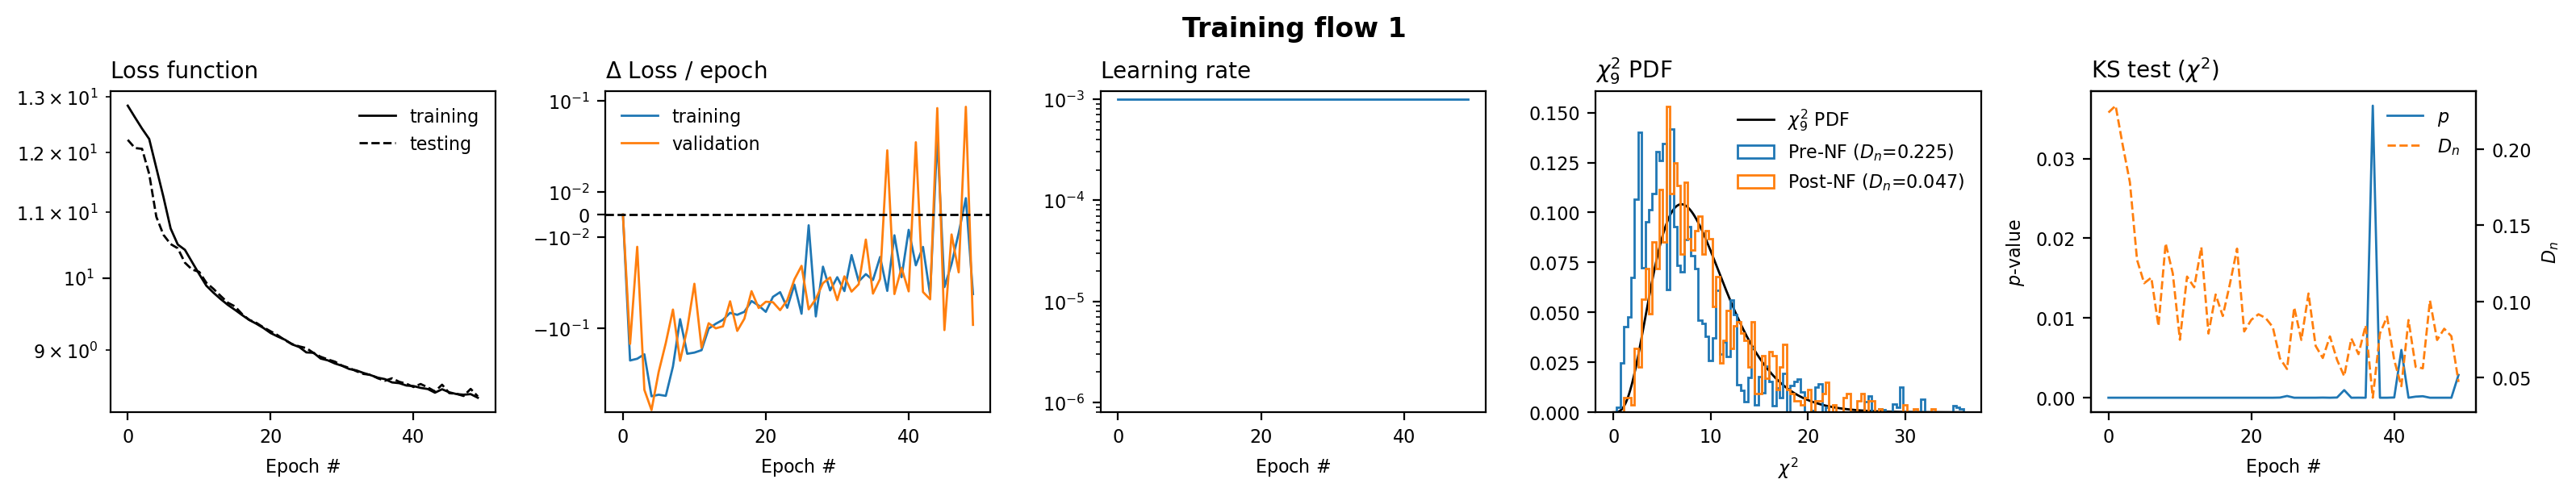

In [20]:
# most methods are implemented for the average flow as well:
average_flow_exp.training_plot()

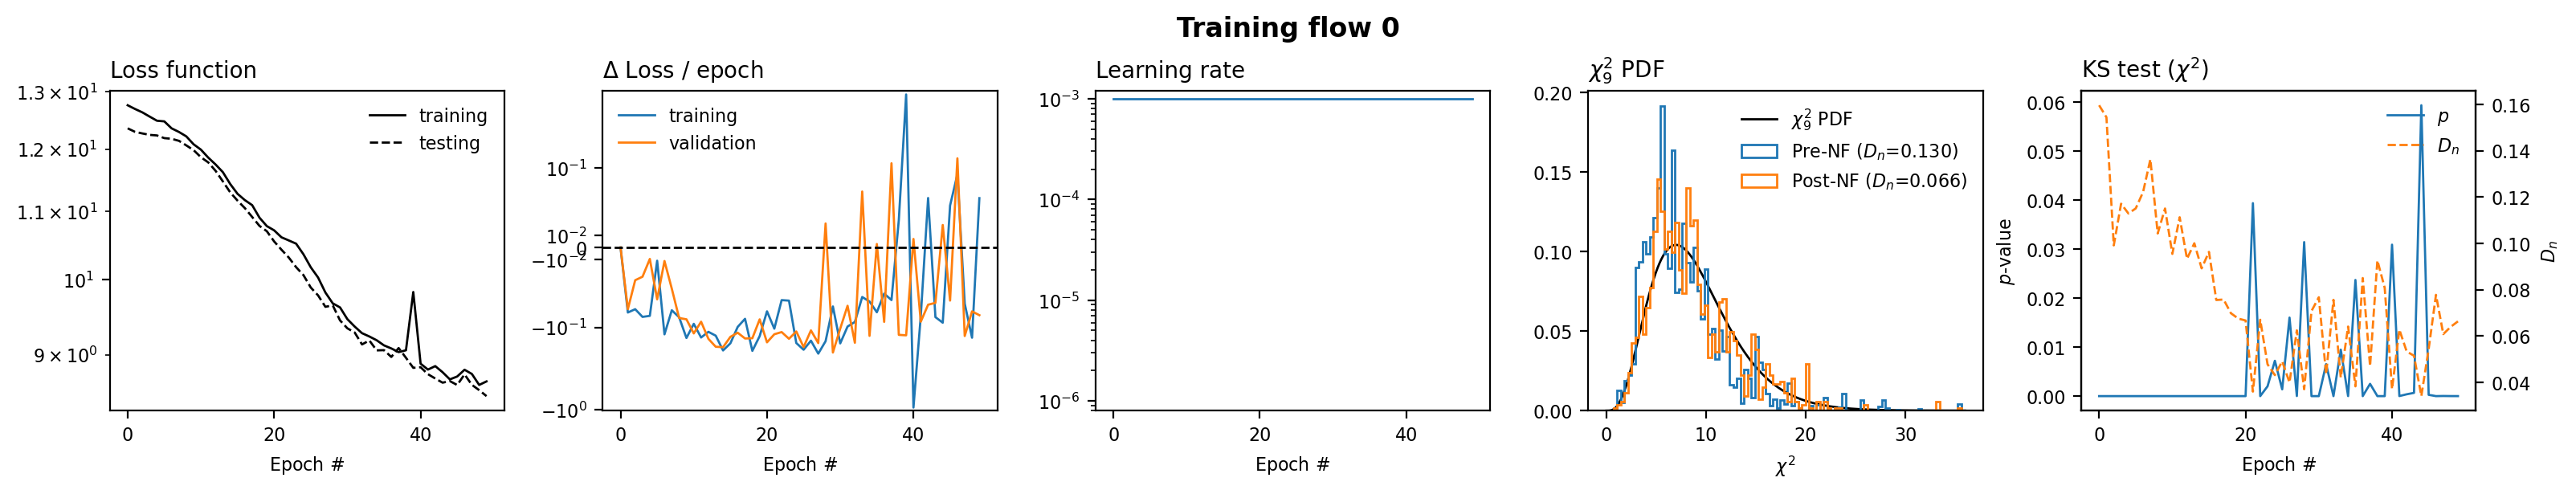

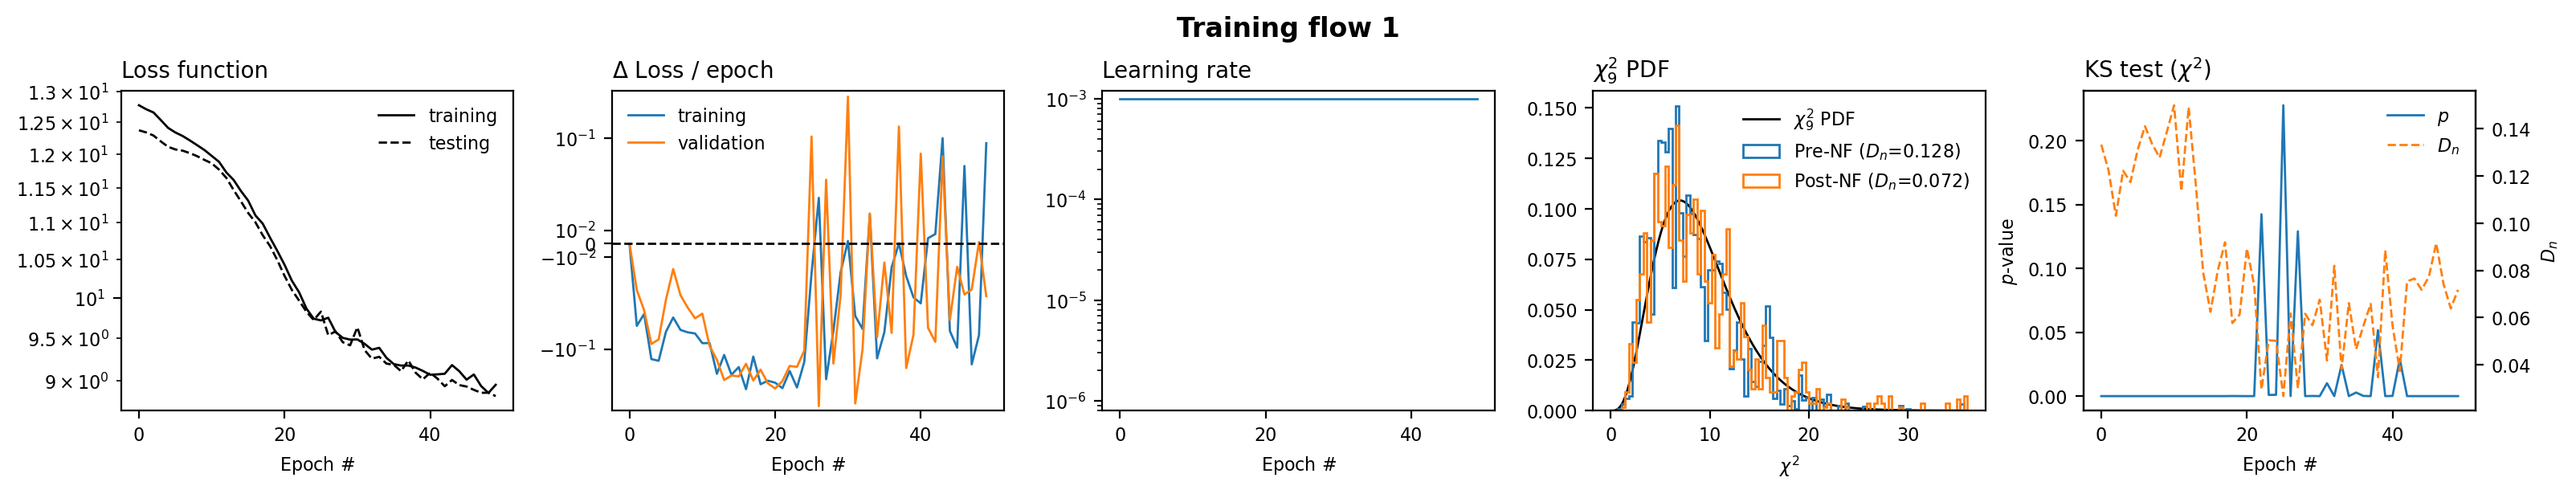

In [21]:
# most methods are implemented for the average flow as well:
average_flow_cos.training_plot()

In [22]:
# and we can print the training summary, which in this case contains more info:
average_flow_lcdm.print_training_summary()

Number of flows: 2
Flow weights   : [0.93 0.07]
loss         : [2.74 5.33]
val_loss     : [2.71 5.25]
lr           : [0. 0.]
chi2Z_ks     : [0.15 0.09]
chi2Z_ks_p   : [9.70e-103 4.23e-038]
loss_rate    : [-0.03 -0.05]
val_loss_rate: [ 0.02 -0.12]


In [23]:
# and we can print the training summary, which in this case contains more info:
average_flow_w0wa.print_training_summary()

Number of flows: 2
Flow weights   : [0.46 0.54]
loss         : [7.17 7.02]
val_loss     : [7.15 7.  ]
lr           : [0. 0.]
chi2Z_ks     : [0.08 0.07]
chi2Z_ks_p   : [1.77e-15 3.69e-14]
loss_rate    : [0.08 0.  ]
val_loss_rate: [-0.03 -0.02]


In [24]:
# and we can print the training summary, which in this case contains more info:
average_flow_exp.print_training_summary()

Number of flows: 2
Flow weights   : [0.61 0.39]
loss         : [7.82 8.4 ]
val_loss     : [7.98 8.42]
lr           : [0. 0.]
chi2Z_ks     : [0.04 0.05]
chi2Z_ks_p   : [0.01 0.  ]
loss_rate    : [-0.05 -0.04]
val_loss_rate: [-0.04 -0.09]


In [25]:
# and we can print the training summary, which in this case contains more info:
average_flow_cos.print_training_summary()

Number of flows: 2
Flow weights   : [0.58 0.42]
loss         : [8.67 8.95]
val_loss     : [8.49 8.83]
lr           : [0. 0.]
chi2Z_ks     : [0.07 0.07]
chi2Z_ks_p   : [3.44e-06 3.58e-07]
loss_rate    : [0.04 0.09]
val_loss_rate: [-0.07 -0.04]


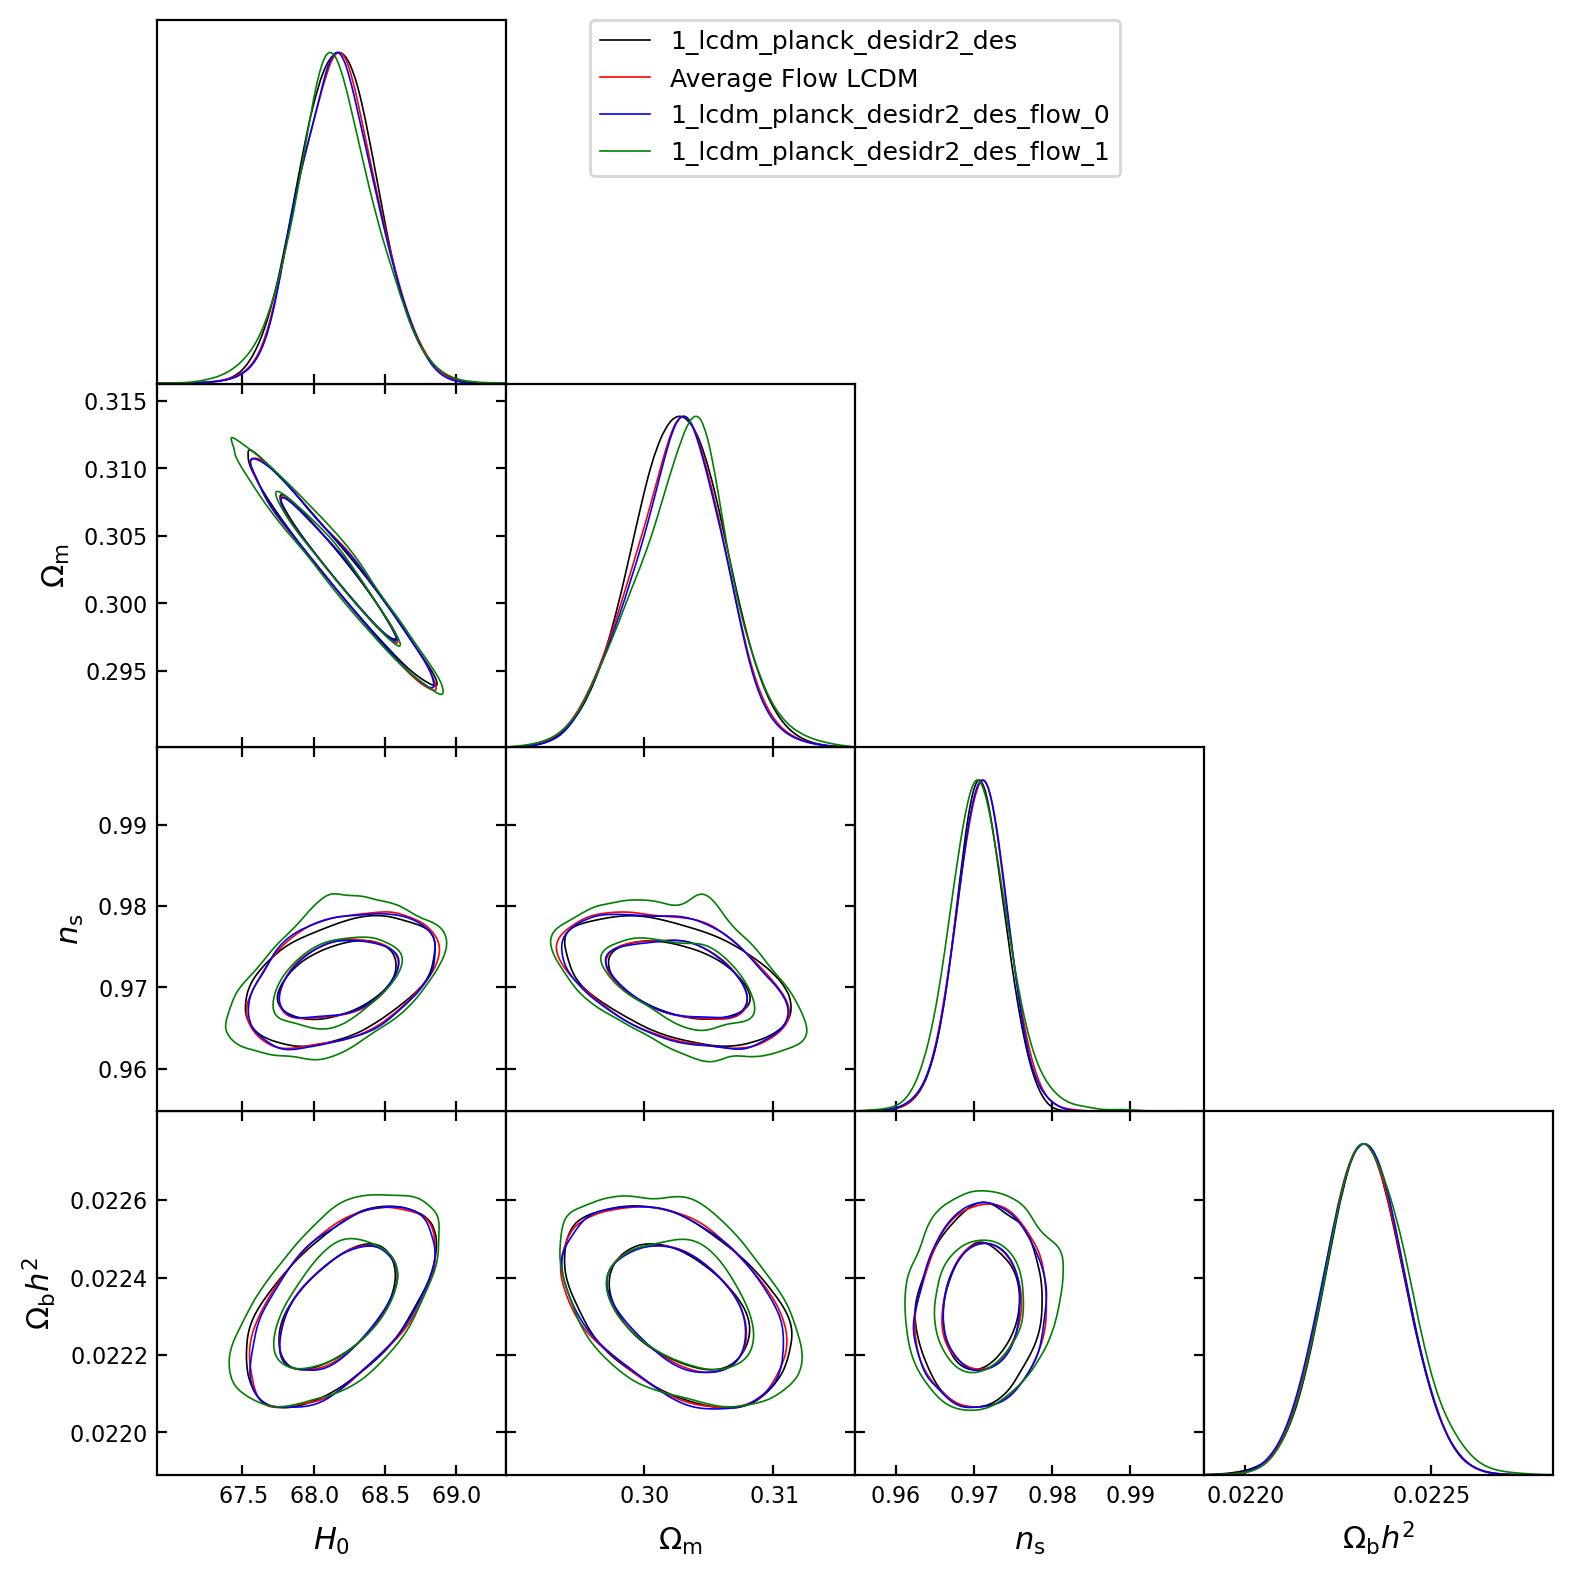

In [26]:

avg_samples_lcdm = average_flow_lcdm.MCSamples(20000)
avg_samples_lcdm.name_tag = 'Average Flow LCDM'
temp_samples_lcdm = [_f.MCSamples(20000) for _f in average_flow_lcdm.flows]
for i, _s in enumerate(temp_samples_lcdm):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
# Define the list of parameters you want to include
params_to_plot = ['H0', 'omegam', 'ns', 'ombh2']
g = plots.get_subplot_plotter()
g.triangle_plot([samples_lcdm, avg_samples_lcdm] + temp_samples_lcdm,
                params=params_to_plot,
                filled=False)


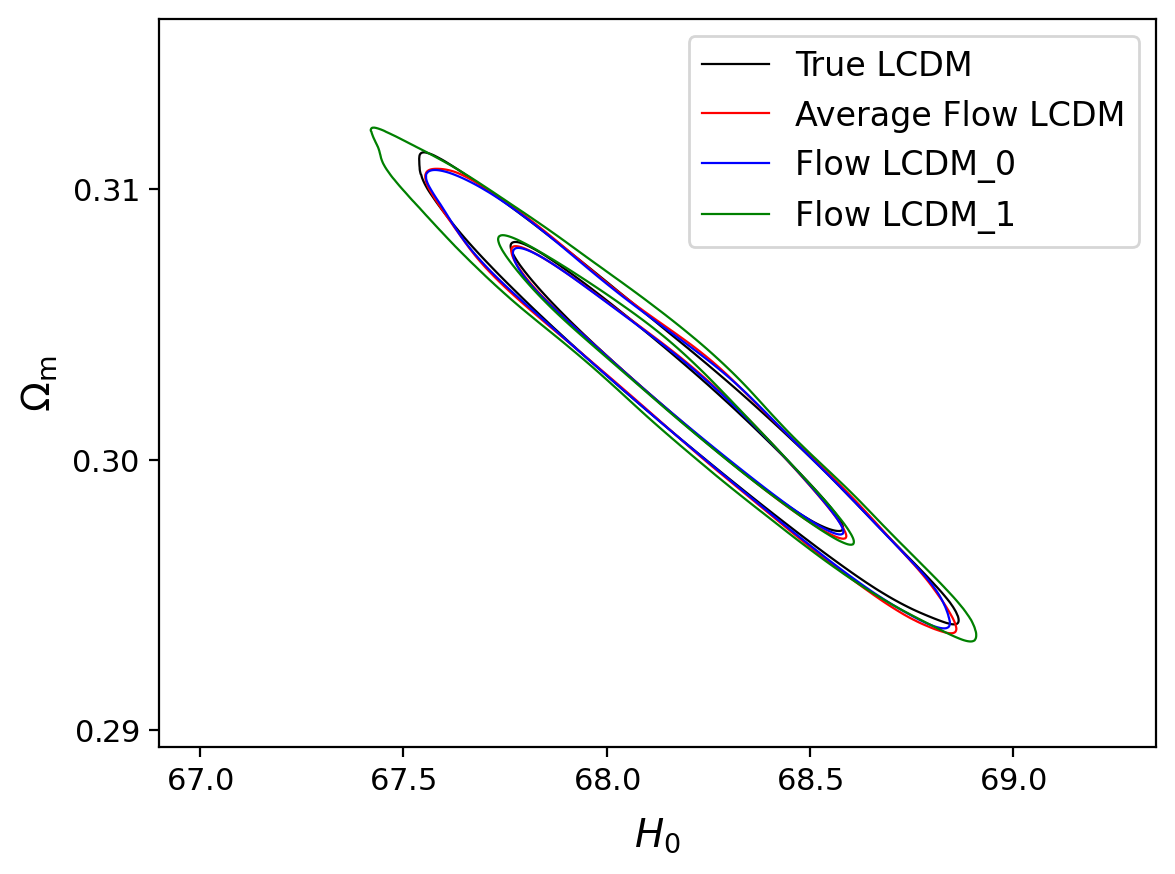

In [ ]:
# 2D Plot H0 and omega_m
# Set all line widths to 0.8 (or whatever you like)
n_total = 2 + len(temp_samples_lcdm)  # total number of samples being plotted
line_args = [{'lw': 0.8}] * n_total  # same style for all

# Create name tags and labels
for i, _s in enumerate(temp_samples_lcdm):
    _s.name_tag = f'Flow LCDM_{i}'
labels = ['True LCDM', 'Average Flow LCDM'] + [s.name_tag for s in temp_samples_lcdm]

# Plot
g = plots.get_single_plotter()
g.plot_2d([samples_lcdm, avg_samples_lcdm] + temp_samples_lcdm,
          ['H0', 'omegam'],
          line_args=line_args)

g.add_legend(labels)



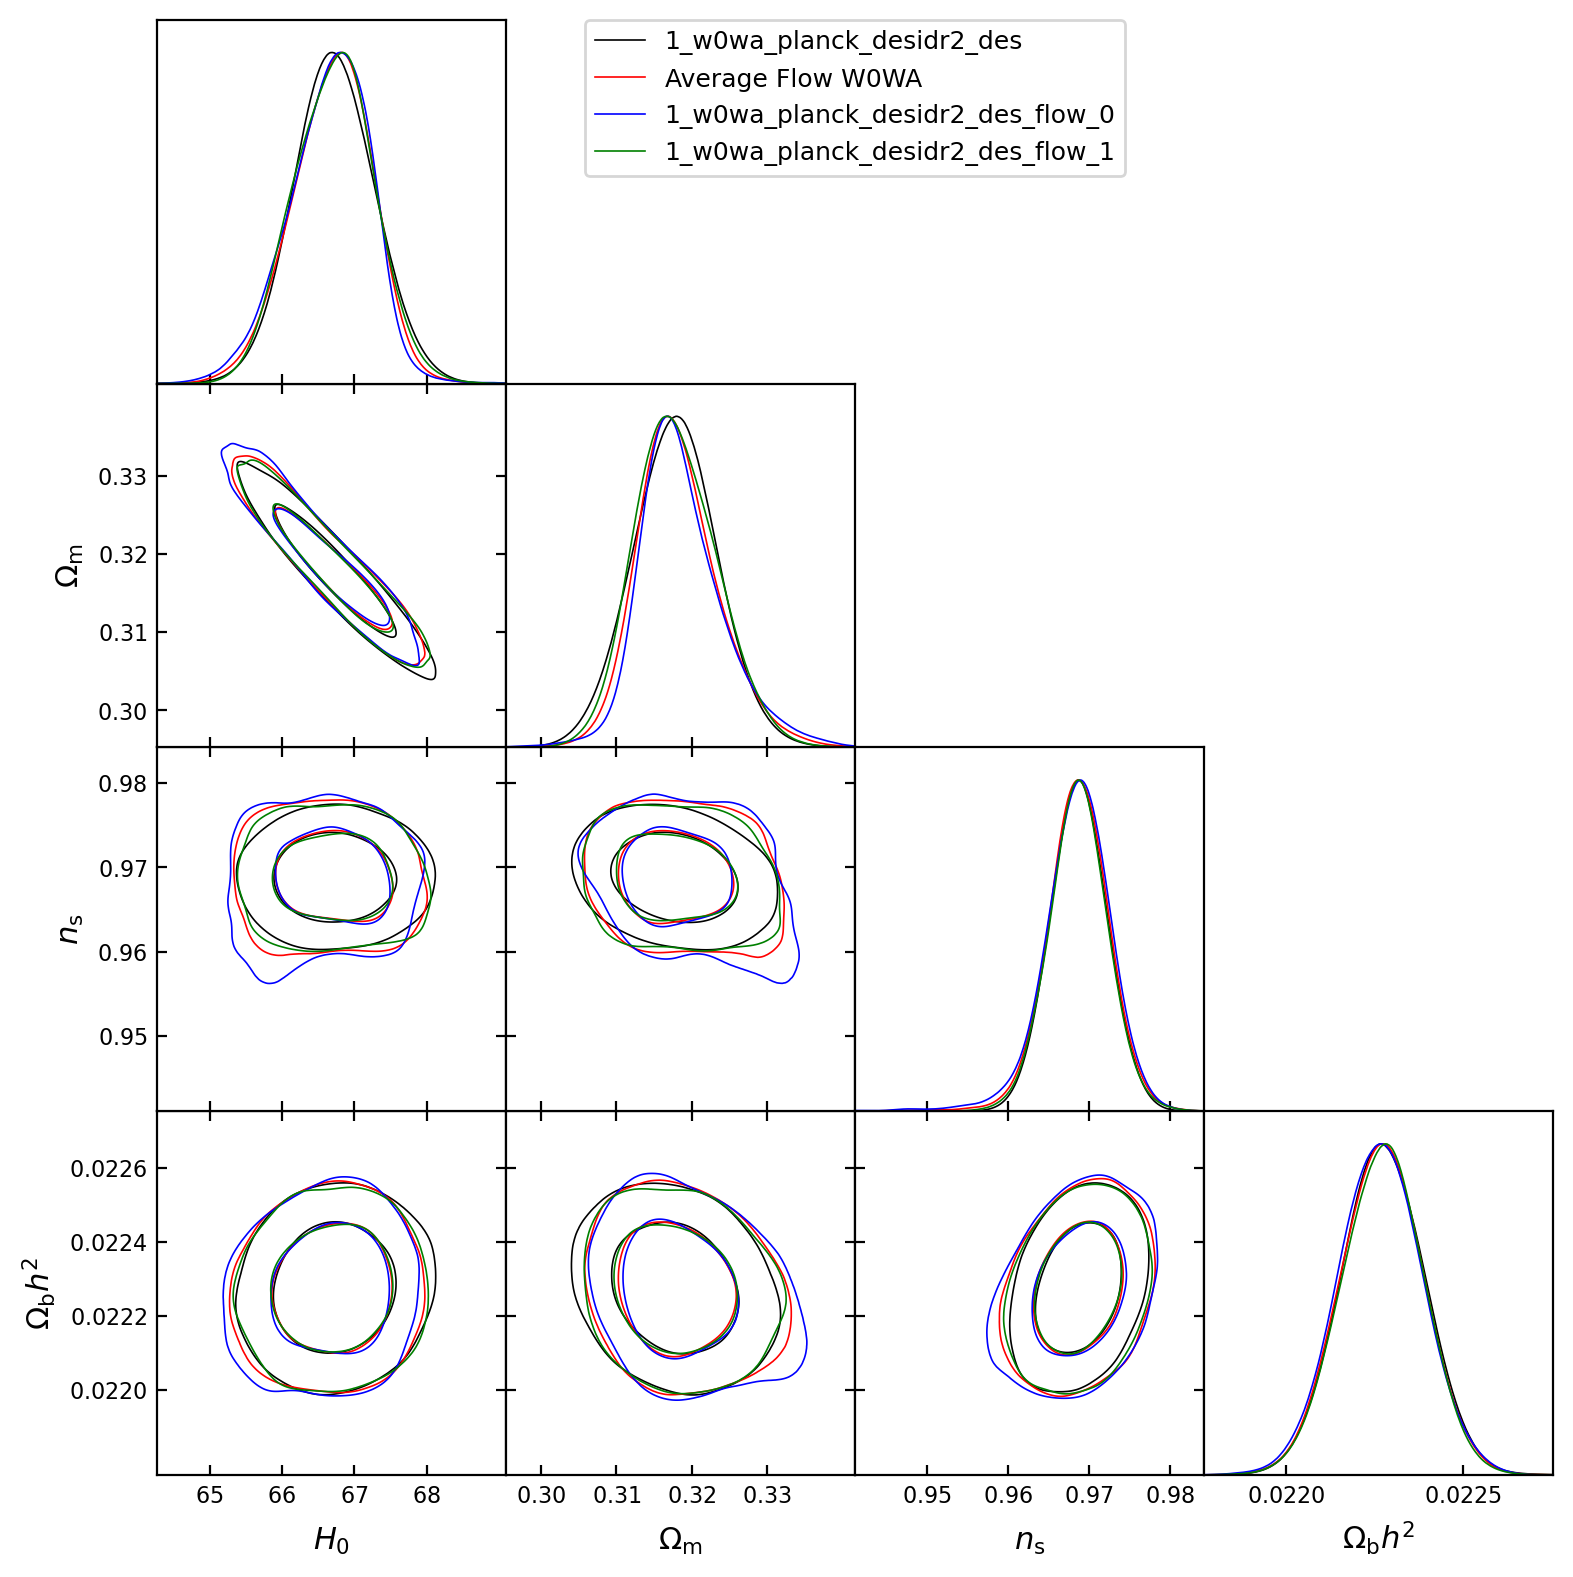

In [28]:

avg_samples_w0wa = average_flow_w0wa.MCSamples(20000)
avg_samples_w0wa.name_tag = 'Average Flow W0WA'
temp_samples_w0wa = [_f.MCSamples(20000) for _f in average_flow_w0wa.flows]
for i, _s in enumerate(temp_samples_w0wa):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
params_to_plot = ['H0', 'omegam', 'ns', 'ombh2']
g = plots.get_subplot_plotter()
g.triangle_plot([samples_w0wa, avg_samples_w0wa] + temp_samples_w0wa,
                params=params_to_plot,
                filled=False)


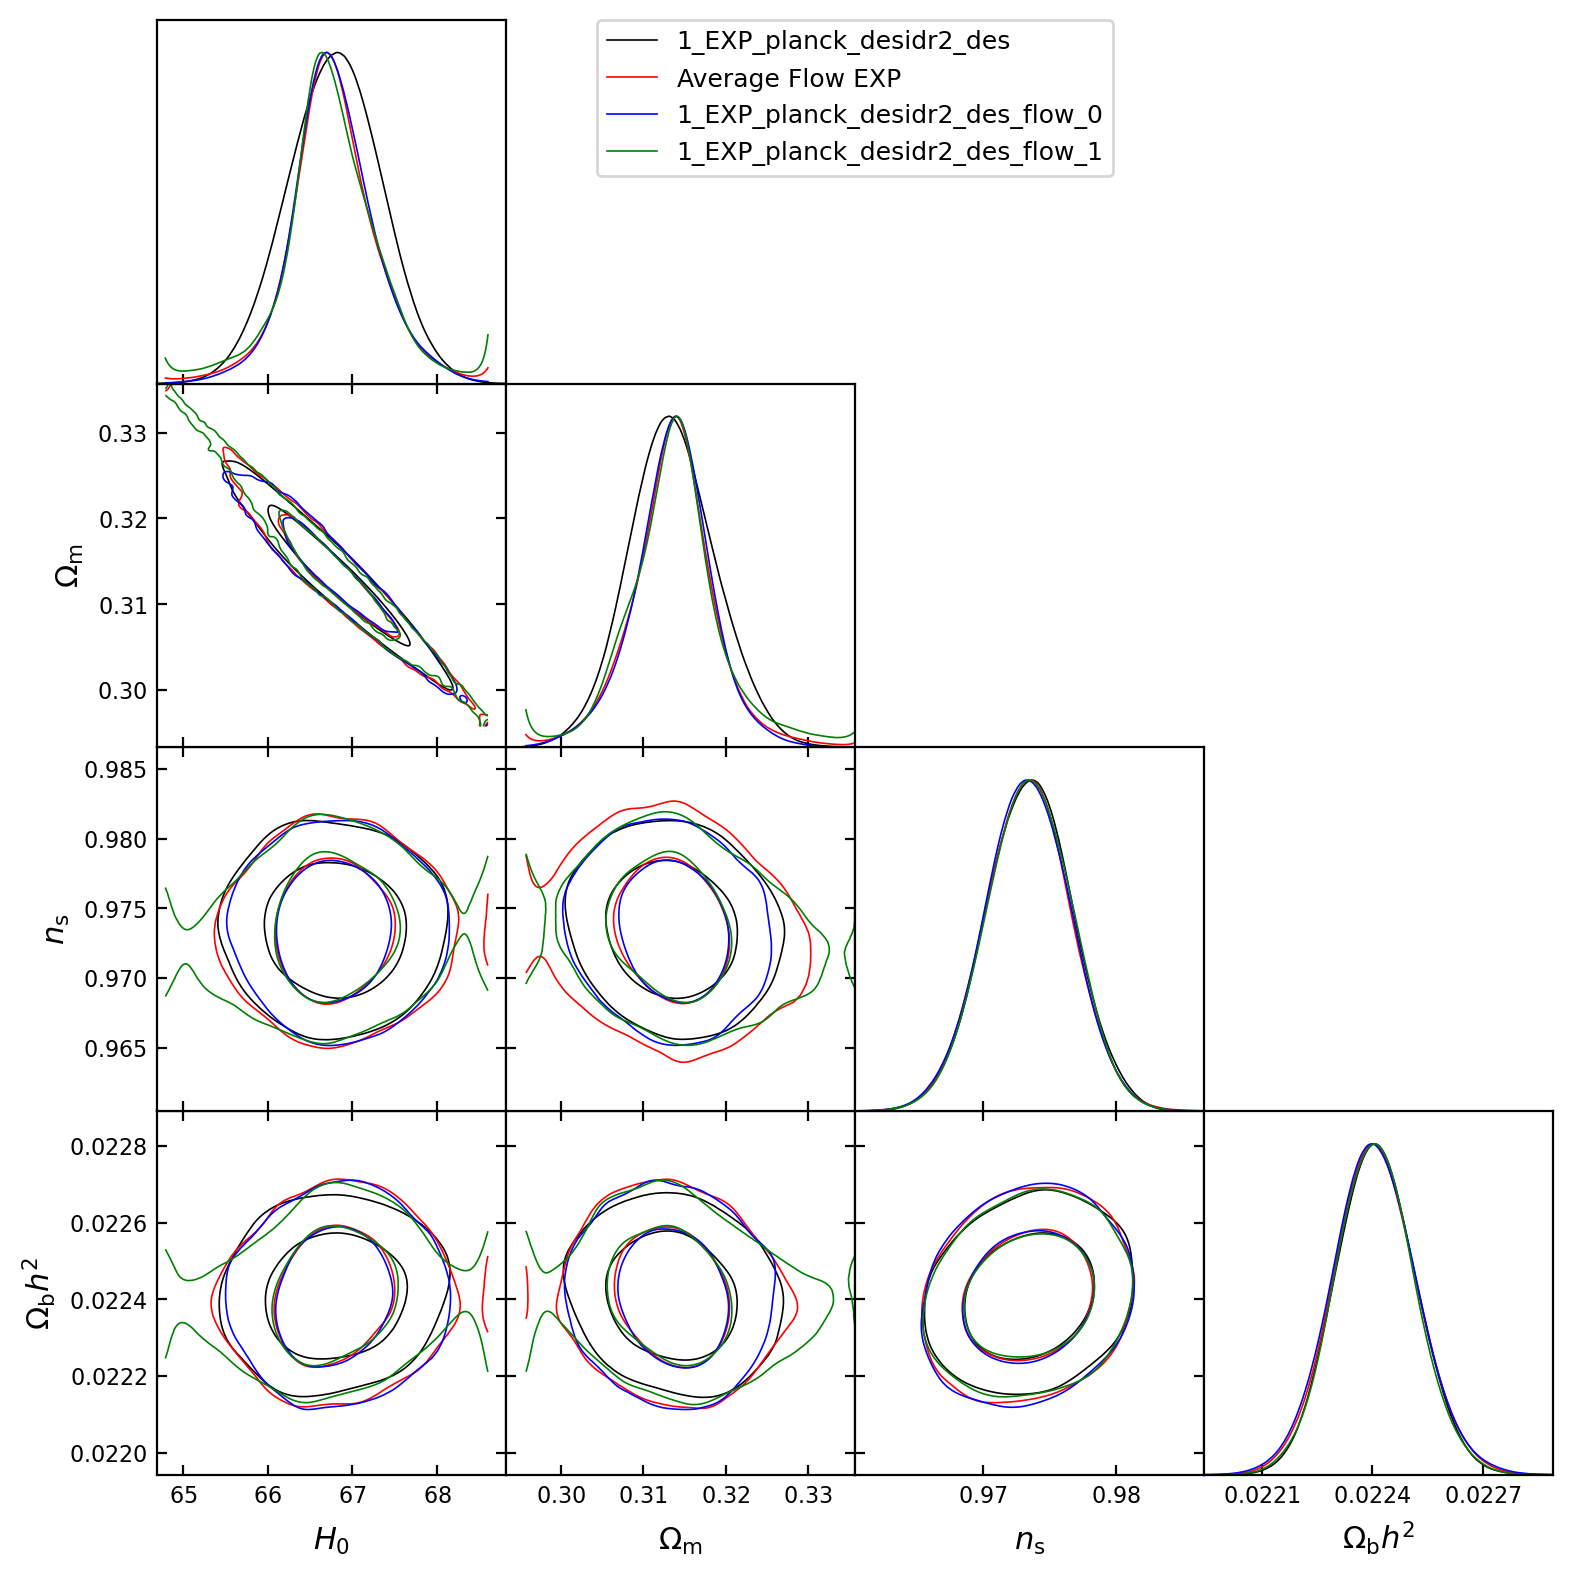

In [29]:

avg_samples_exp = average_flow_exp.MCSamples(20000)
avg_samples_exp.name_tag = 'Average Flow EXP'
temp_samples_exp = [_f.MCSamples(20000) for _f in average_flow_exp.flows]
for i, _s in enumerate(temp_samples_exp):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
params_to_plot = ['H0', 'omegam', 'ns', 'ombh2']
g = plots.get_subplot_plotter()
g.triangle_plot([samples_exp, avg_samples_exp] + temp_samples_exp,
                params=params_to_plot,
                filled=False)


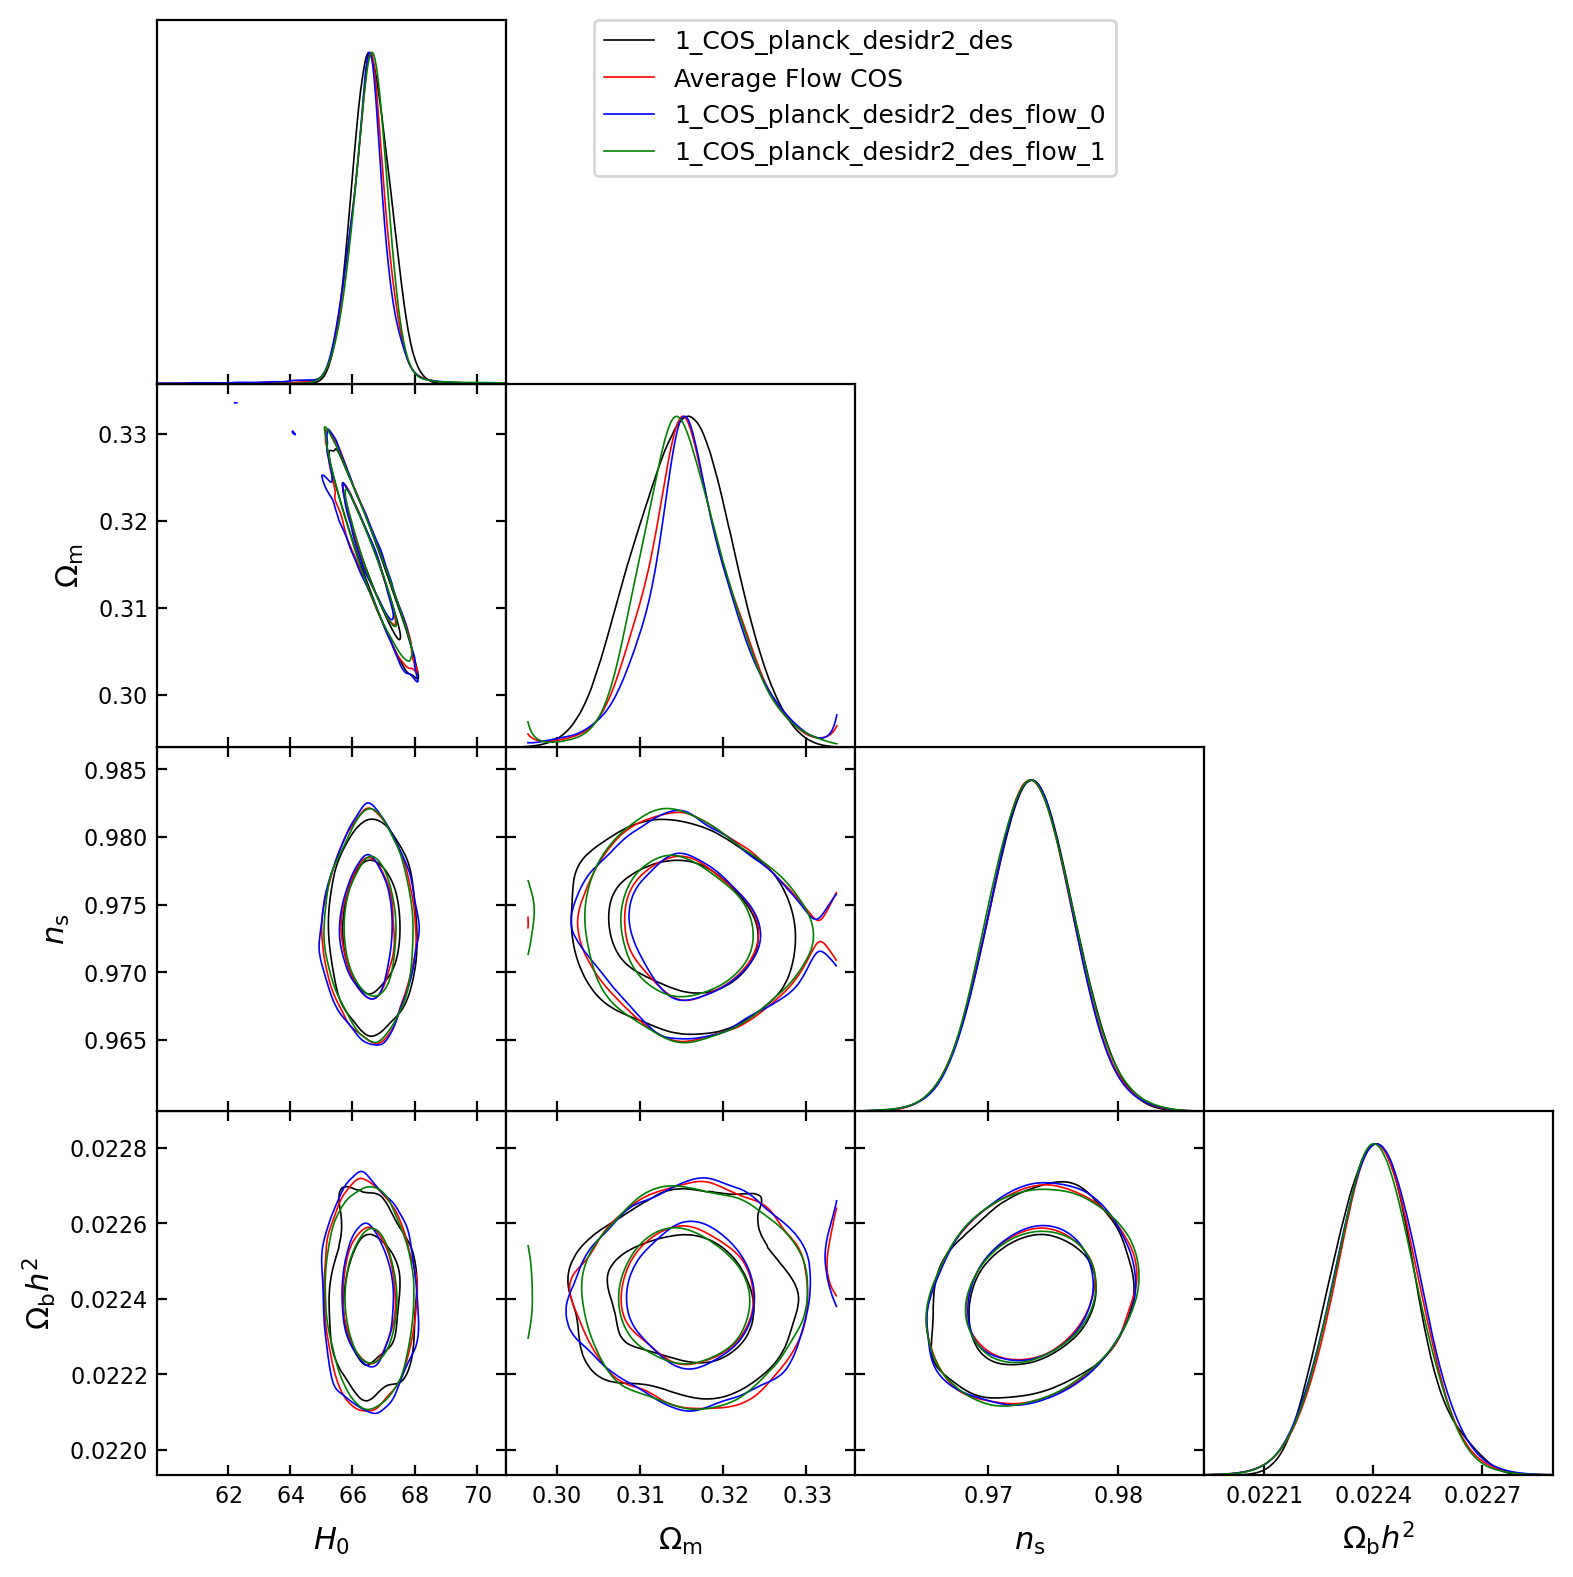

In [30]:

avg_samples_cos = average_flow_cos.MCSamples(20000)
avg_samples_cos.name_tag = 'Average Flow COS'
temp_samples_cos = [_f.MCSamples(20000) for _f in average_flow_cos.flows]
for i, _s in enumerate(temp_samples_cos):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
params_to_plot = ['H0', 'omegam', 'ns', 'ombh2']
g = plots.get_subplot_plotter()
g.triangle_plot([samples_cos, avg_samples_cos] + temp_samples_cos,
                params=params_to_plot,
                filled=False)


In [31]:
ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = average_flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')

ev_cos, eer_cos = average_flow_cos.evidence(weighted=True)
print(f'COS: log(Z) = {ev_cos} +- {eer_cos}')

LCDM: log(Z) = -16216.390234230823 +- 2.4276781723581666
W0WA: log(Z) = -16203.011337747883 +- 2.063705942154699
EXP: log(Z) = -16211.291839601028 +- 2.7205946616976906
COS: log(Z) = -16209.611689087758 +- 2.5729144385426017


### Advanced Topic: Evidence 

['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'omegam', 'sigma8']
First few values of validation_flow_log10_P: [21.336647 20.910734 22.476904]
First few values of training_flow_log10_P: [21.336155 19.53629  18.71721 ]
Mean training difference: 13.868756686179712
Mean validation difference: 13.88731009149188
Sigma training difference: 1.6973133847956863
Sigma validation difference: 1.7166416616340636
Number of training points far from the mean: 381
Number of validation points far from the mean: 29


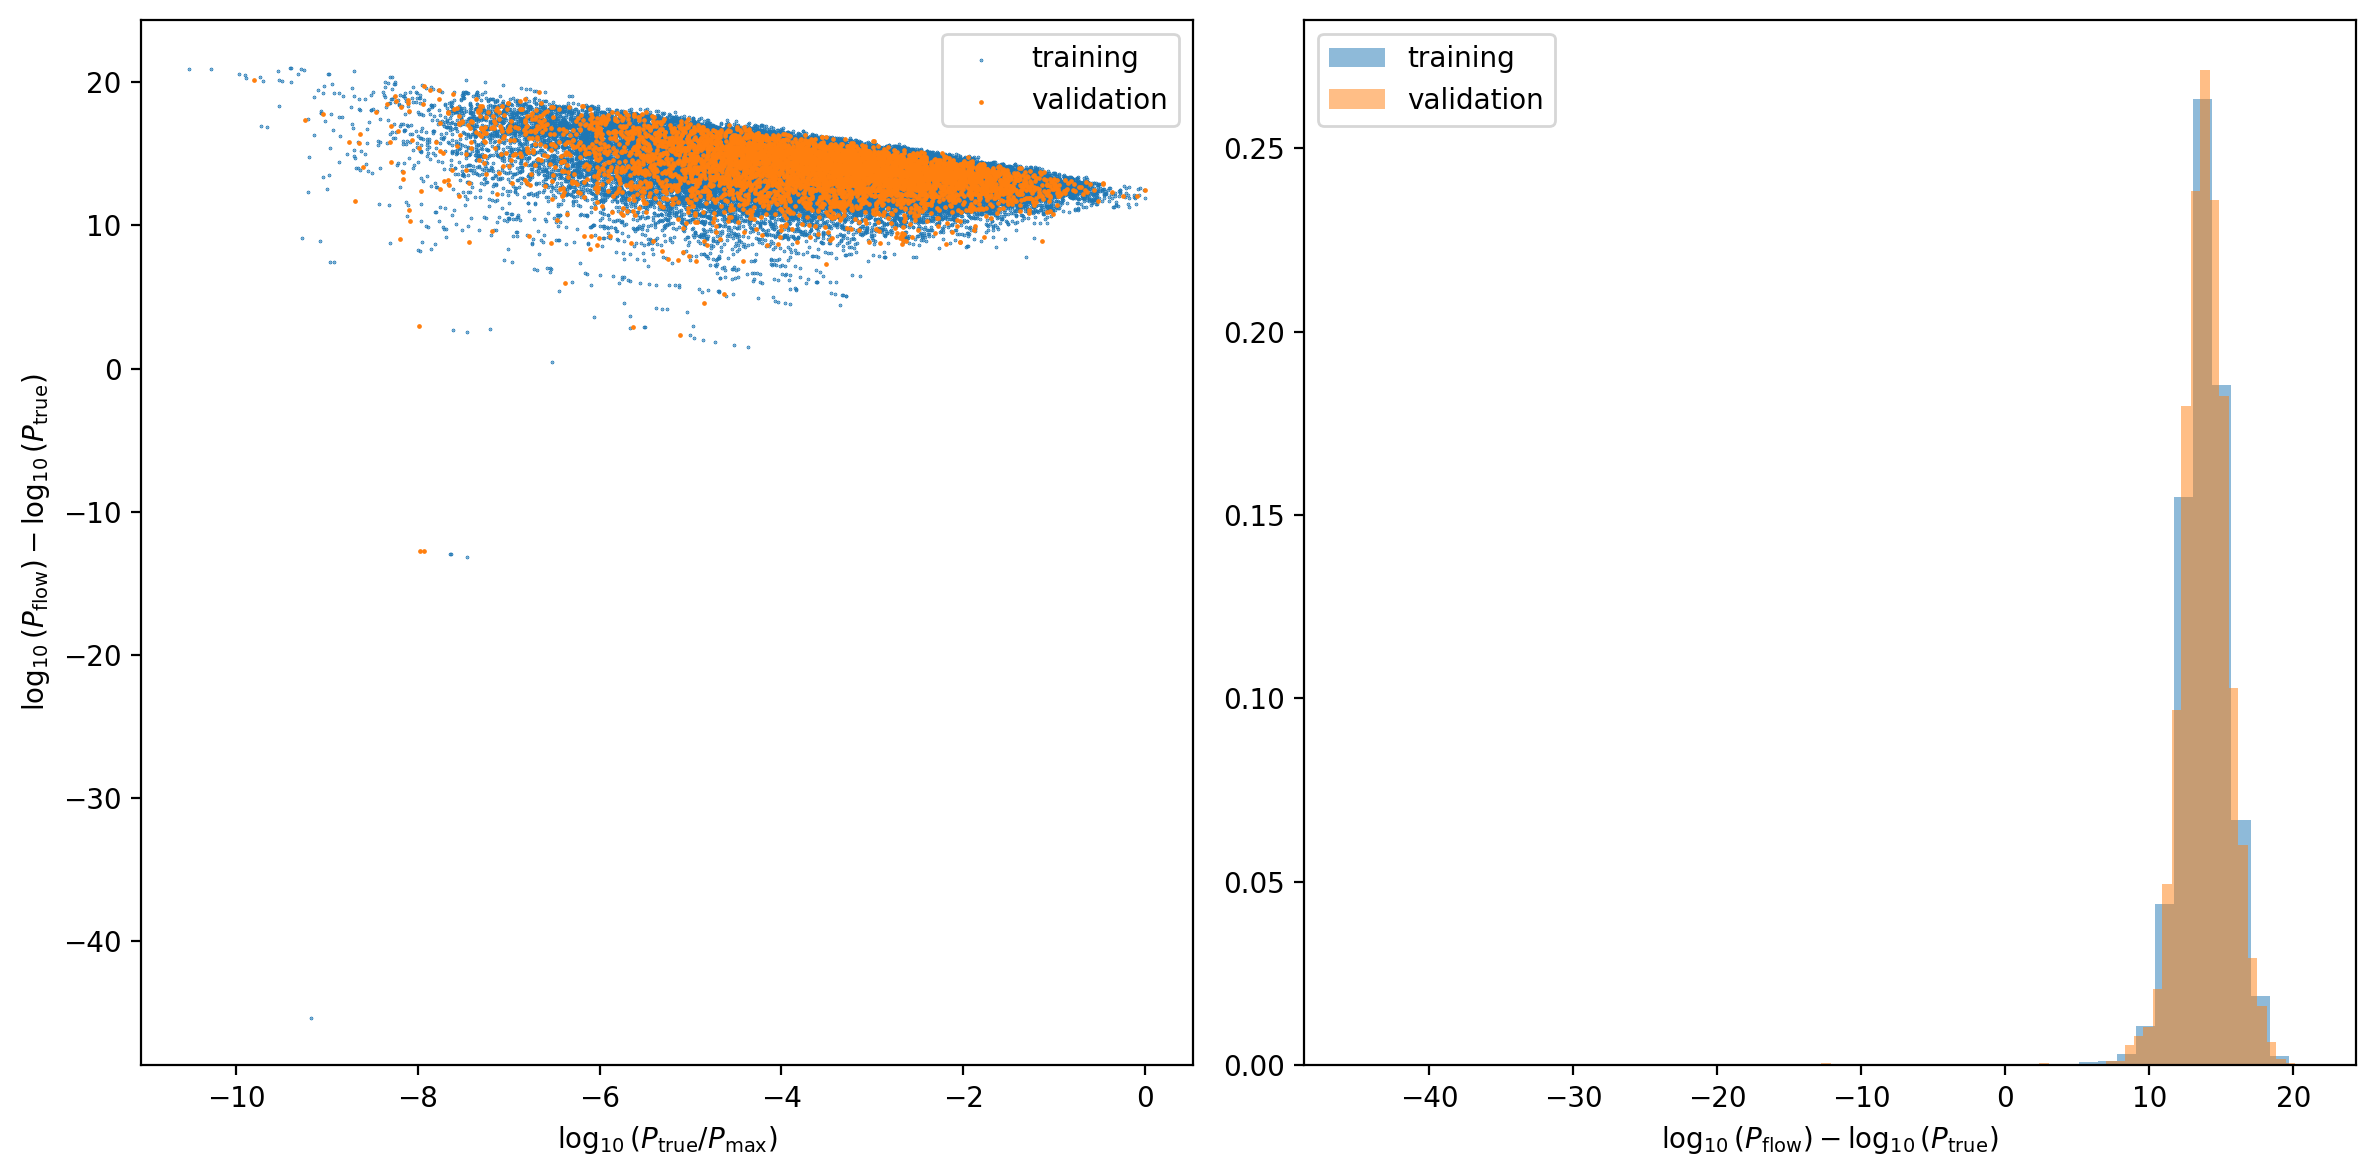

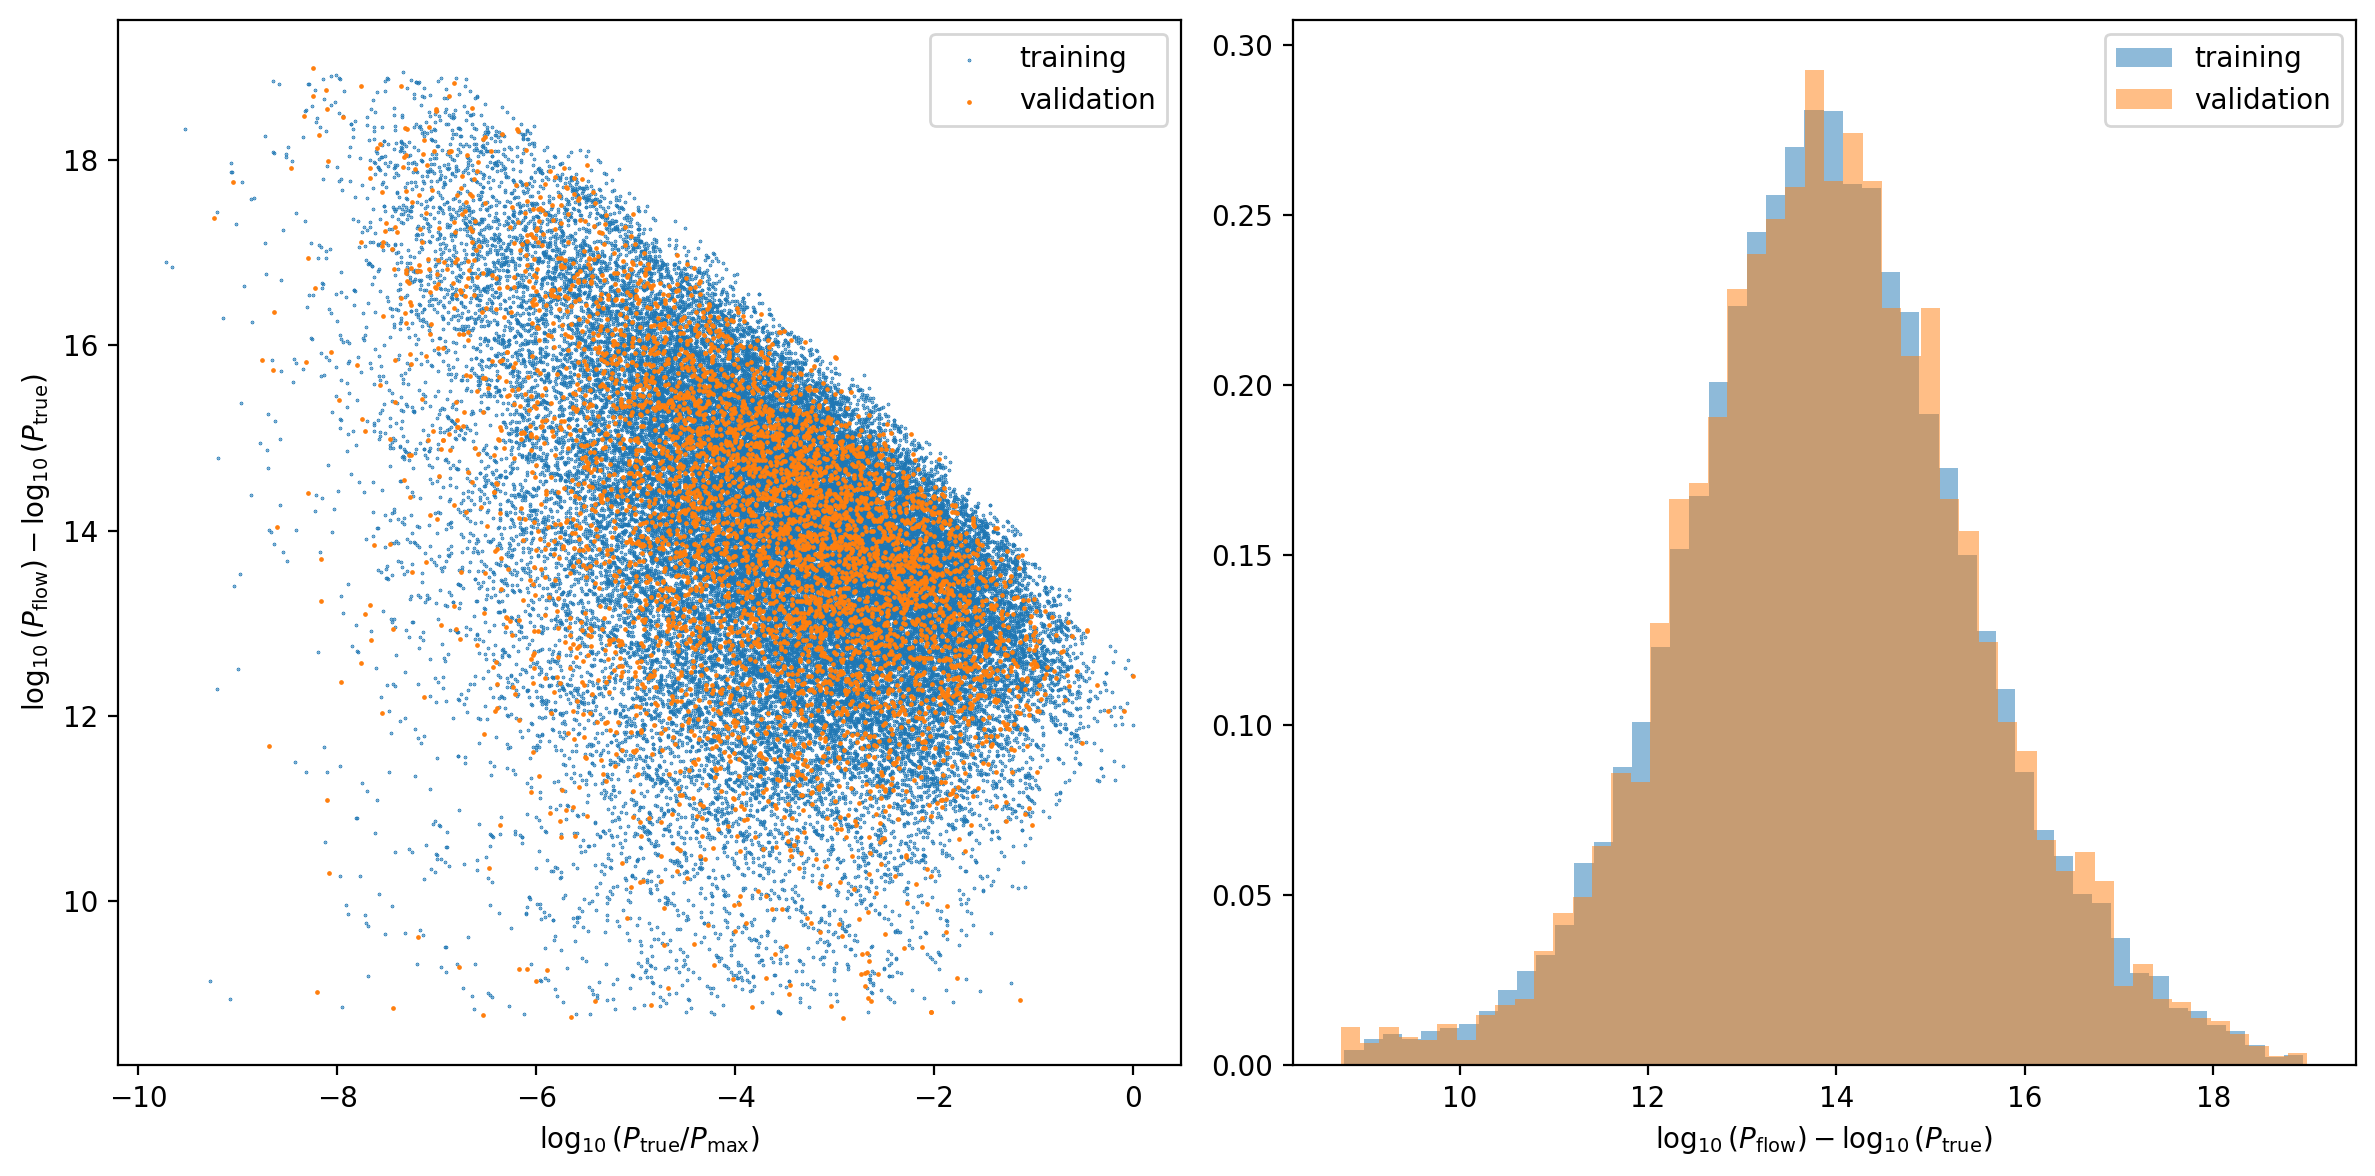

In [49]:
# Convert param names in samples to strings
stri = ['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']

param_names_all = [str(p) for p in stri]

# Params used in the flow
param_names = average_flow_lcdm.param_names
print(param_names)
# Get corresponding indices
param_indices = [param_names_all.index(p) for p in param_names]

# Select only the needed parameters from test samples
x = samples_lcdm.samples[average_flow_lcdm.test_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability
casted = average_flow_lcdm.cast(x)

validation_flow_log10_P = average_flow_lcdm.log_probability(casted).numpy() / np.log(10.) # VALIDATION FLOW
# Print the first few values of validation_flow_log10_P
print("First few values of validation_flow_log10_P:", validation_flow_log10_P[:3])

x_training = samples_lcdm.samples[average_flow_lcdm.training_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability for training samples
casted_training = average_flow_lcdm.cast(x_training)
training_flow_log10_P = average_flow_lcdm.log_probability(casted_training).numpy() / np.log(10.) # TRAINING FLOW

# Print the first few values of training_flow_log10_P
print("First few values of training_flow_log10_P:", training_flow_log10_P[:3])

#for i, name in enumerate(param_names):
 #   print(f"{i:2d}: {name:15s} --> values: {x[:3, i]}")

# Remove the loglikes from the samples:
loglike_max = np.max(samples_lcdm.loglikes)
validation_samples_log10_P = -(samples_lcdm.loglikes[average_flow_lcdm.test_idx] - loglike_max) / np.log(10.)
training_samples_log10_P = -(samples_lcdm.loglikes[average_flow_lcdm.training_idx] - loglike_max) / np.log(10.)    

#print("Training flow - true log10(P):", np.min(training_flow_log10_P - training_samples_log10_P), np.max(training_flow_log10_P - training_samples_log10_P))
#print("Validation flow - true log10(P):", np.min(validation_flow_log10_P - validation_samples_log10_P), np.max(validation_flow_log10_P - validation_samples_log10_P))

mean_training = np.mean(training_flow_log10_P - training_samples_log10_P)
mean_validation = np.mean(validation_flow_log10_P - validation_samples_log10_P)
print("Mean training difference:", mean_training)
print("Mean validation difference:", mean_validation)

sigma_training = np.std(training_flow_log10_P - training_samples_log10_P)
sigma_validation = np.std(validation_flow_log10_P - validation_samples_log10_P)
print("Sigma training difference:", sigma_training)
print("Sigma validation difference:", sigma_validation)

# Difference between each point and the mean:
training_flow_diff = (training_flow_log10_P - training_samples_log10_P) - mean_training
validation_flow_diff = (validation_flow_log10_P - validation_samples_log10_P) - mean_validation

threshold_training = 3*sigma_training
threshold_validation = 3*sigma_validation  
cont_train = 0
cont_val = 0
validation_samples_log10_P_del = []
validation_flow_log10_P_del = []
training_flow_log10_P_del = []
training_samples_log10_P_del = []

# I want to see which points are far from the mean and save another array with all points without the removed points:
for i, diff in enumerate(training_flow_diff):
    if np.abs(diff) > threshold_training:
        #print(f"Training point {i} is far from the mean: {diff}")
        cont_train += 1
        # create a new array with the points that are not far from the mean:
    else:
        training_samples_log10_P_del.append(training_samples_log10_P[i])
        training_flow_log10_P_del.append(training_flow_log10_P[i])
        #print(f"Training point {i} is not far from the mean: {diff}")

for i, diff in enumerate(validation_flow_diff):
    if np.abs(diff) > threshold_validation:
        #print(f"Validation point {i} is far from the mean: {diff}")
        cont_val += 1
        # create a new array with the points that are not far from the mean:
    else:
        validation_samples_log10_P_del.append(validation_samples_log10_P[i])
        validation_flow_log10_P_del.append(validation_flow_log10_P[i])
        #print(f"Validation point {i} is not far from the mean: {diff}")
        
print(f"Number of training points far from the mean: {cont_train}")
print(f"Number of validation points far from the mean: {cont_val}")

# Convert lists to numpy arrays:
training_samples_log10_P_del = np.array(training_samples_log10_P_del)
training_flow_log10_P_del = np.array(training_flow_log10_P_del)
validation_samples_log10_P_del = np.array(validation_samples_log10_P_del)
validation_flow_log10_P_del = np.array(validation_flow_log10_P_del)

# do the plot:
# with all the points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(training_samples_log10_P - np.amax(training_samples_log10_P), training_flow_log10_P - training_samples_log10_P, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P - np.amax(validation_samples_log10_P), validation_flow_log10_P - validation_samples_log10_P, s=0.5, label='validation')
ax1.legend()
#ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)

ax2.hist(training_flow_log10_P - training_samples_log10_P, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P - validation_samples_log10_P, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
#ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])

plt.tight_layout()
plt.show()


# Do the same thing but without the removed points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del - np.amax(training_samples_log10_P_del), training_flow_log10_P_del - training_samples_log10_P_del, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del - np.amax(validation_samples_log10_P_del), validation_flow_log10_P_del - validation_samples_log10_P_del, s=0.5, label='validation')
ax1.legend()
#ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)    
ax2.hist(training_flow_log10_P_del - training_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del - validation_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
#ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])  
plt.tight_layout()
plt.show()

In [50]:
# Compute the new evidence:
training_filtered_indices_lcdm = [
    i for i, diff in enumerate(training_flow_diff)
    if np.abs(diff) <= threshold_training
]


ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(indexes= training_filtered_indices_lcdm, 
                                               weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

LCDM: log(Z) = -16216.428932779596 +- 2.4127067312654806


In [51]:
# W0WA:

['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'omegam', 'sigma8']
First few values of validation_flow_log10_P: [18.06766  17.102095 18.308819]
First few values of training_flow_log10_P: [16.733397 17.117048 18.271238]
Mean training difference: 9.061083861797096
Mean validation difference: 9.093235207313644
Training flow difference: [-1.24462163 -1.6561631  -1.25026243]
Validation flow difference: [1.66220798 0.7322554  0.64261054]
Threshold training: 5.286405820171945
Threshold validation: 4.90213186413871
Number of training points far from the mean: 113
Number of validation points far from the mean: 19


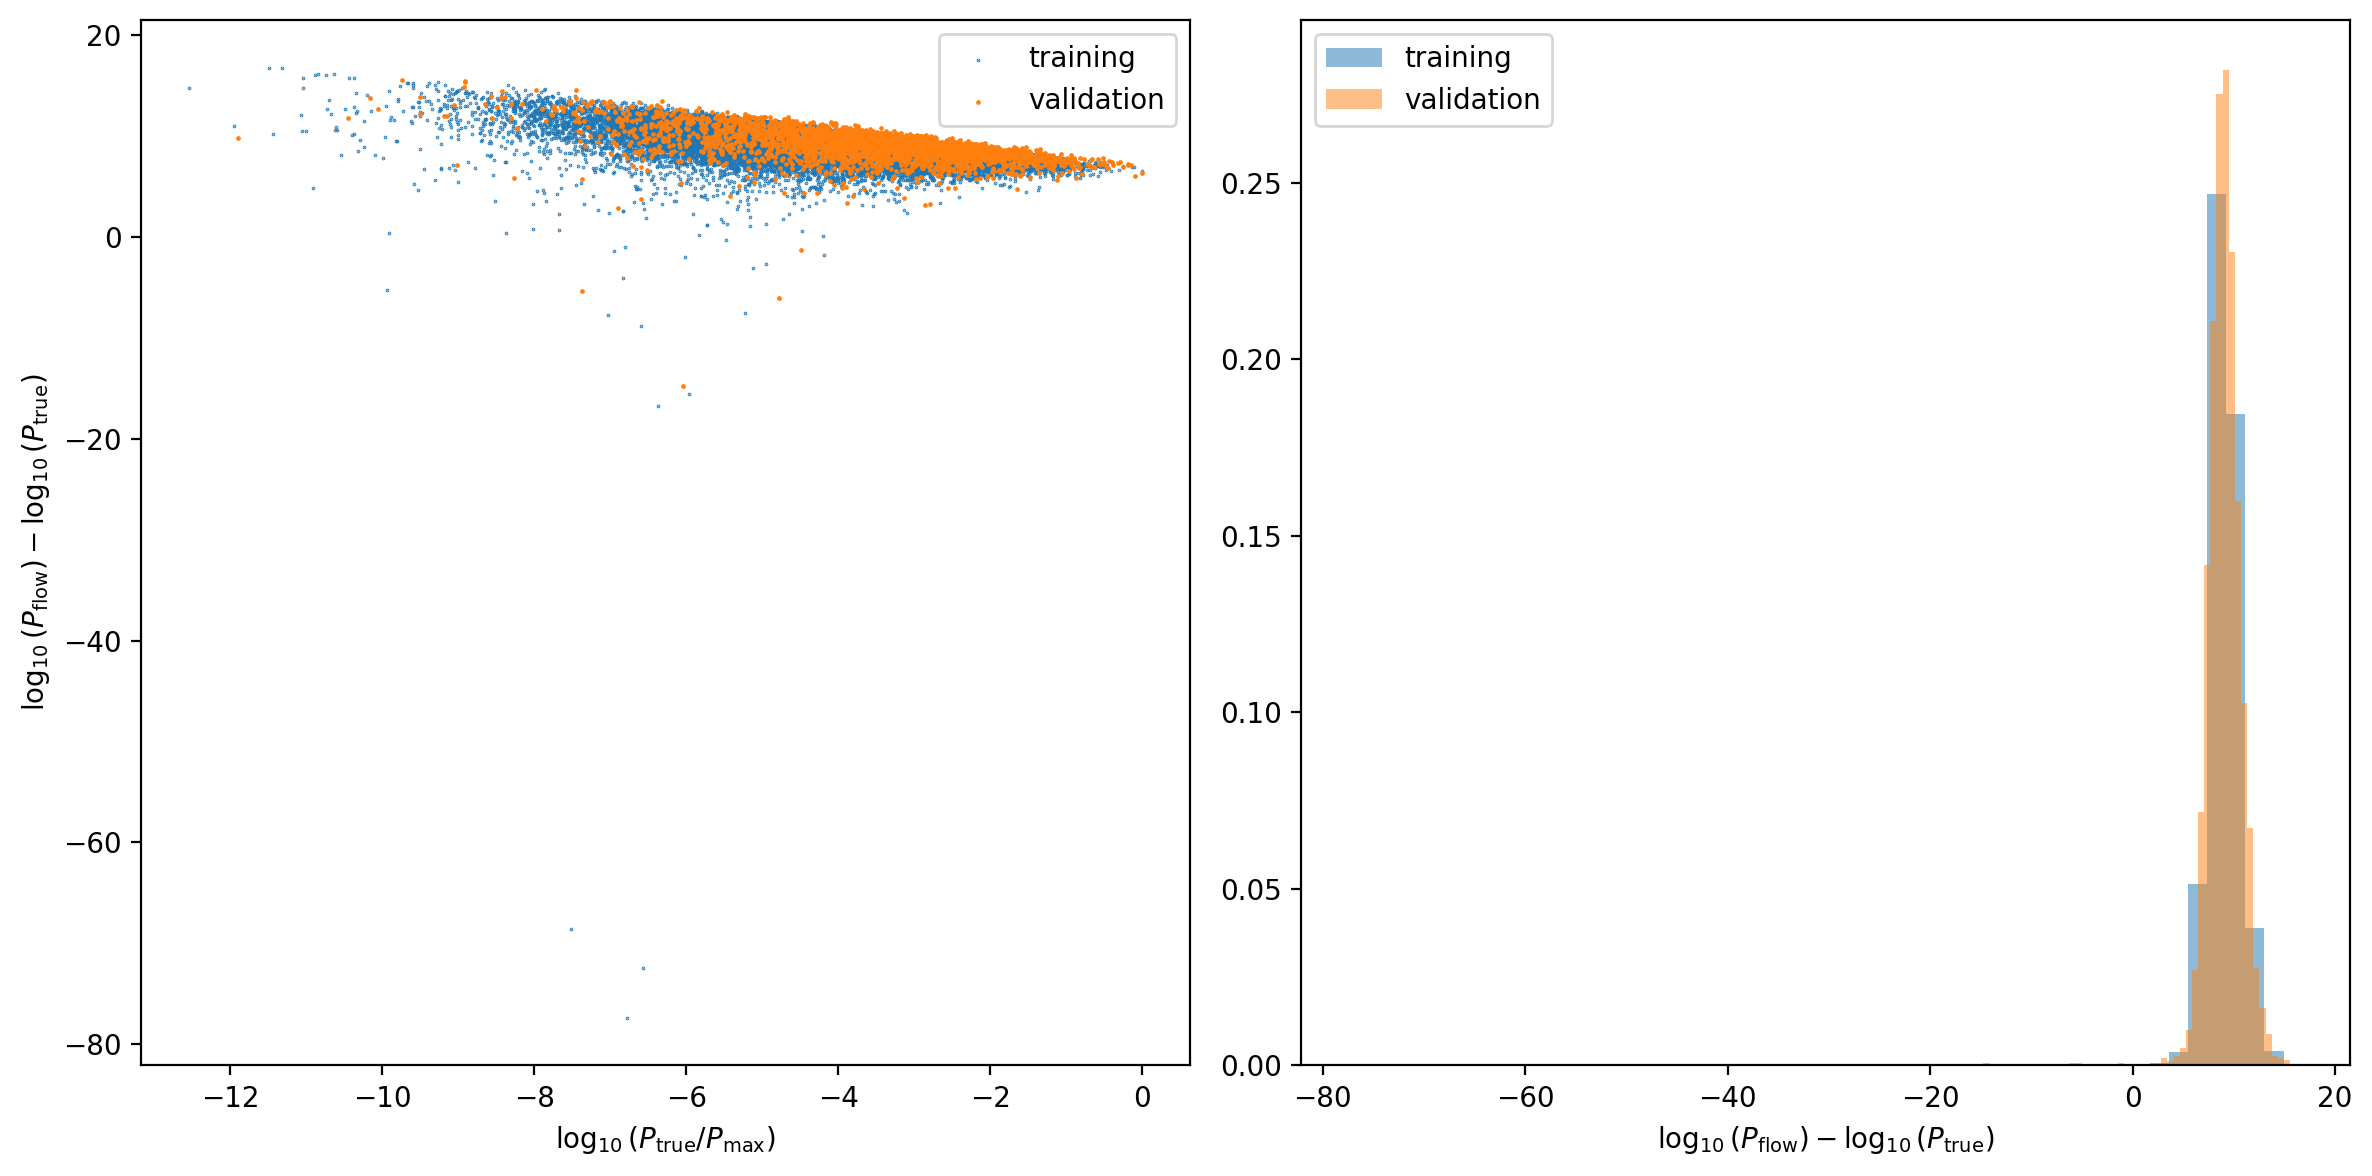

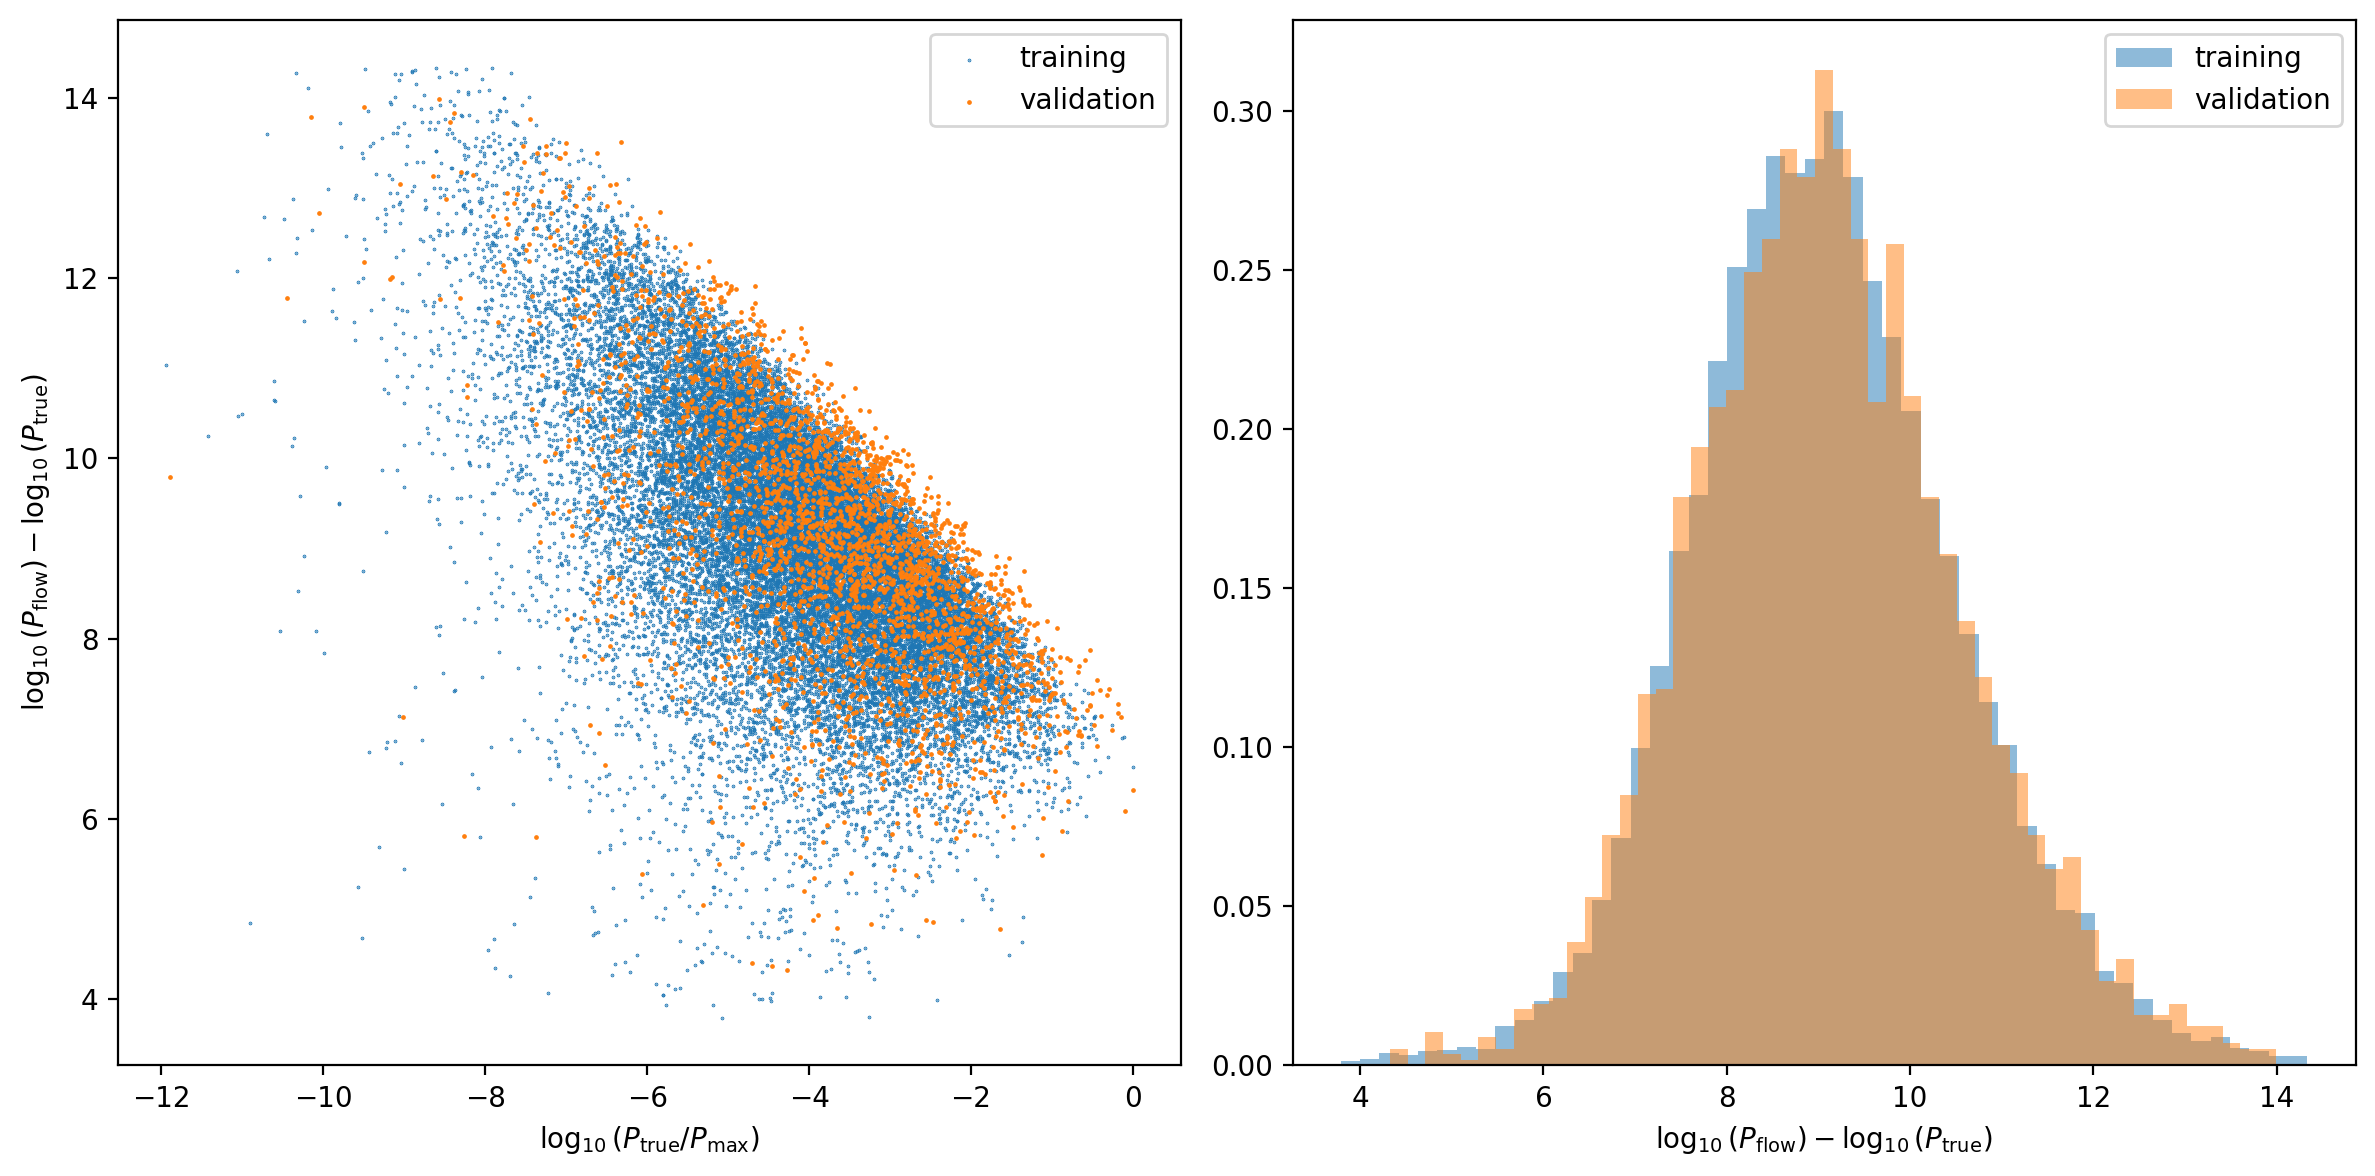

In [52]:
# Convert param names in samples to strings
stri = ['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']

param_names_all = [str(p) for p in stri]

# Params used in the flow
param_names = average_flow_w0wa.param_names
print(param_names)
# Get corresponding indices
param_indices = [param_names_all.index(p) for p in param_names]

# Select only the needed parameters from test samples
x = samples_w0wa.samples[average_flow_w0wa.test_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability
casted = average_flow_w0wa.cast(x)

validation_flow_log10_P = average_flow_w0wa.log_probability(casted).numpy() / np.log(10.) # VALIDATION FLOW
# Print the first few values of validation_flow_log10_P
print("First few values of validation_flow_log10_P:", validation_flow_log10_P[:3])

x_training = samples_w0wa.samples[average_flow_w0wa.training_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability for training samples
casted_training = average_flow_w0wa.cast(x_training)
training_flow_log10_P = average_flow_w0wa.log_probability(casted_training).numpy() / np.log(10.) # TRAINING FLOW

# Print the first few values of training_flow_log10_P
print("First few values of training_flow_log10_P:", training_flow_log10_P[:3])

#for i, name in enumerate(param_names):
 #   print(f"{i:2d}: {name:15s} --> values: {x[:3, i]}")

# Remove the loglikes from the samples:
loglike_max = np.max(samples_w0wa.loglikes)
validation_samples_log10_P = -(samples_w0wa.loglikes[average_flow_w0wa.test_idx] - loglike_max) / np.log(10.)
training_samples_log10_P = -(samples_w0wa.loglikes[average_flow_w0wa.training_idx] - loglike_max) / np.log(10.)    

#print("Training flow - true log10(P):", np.min(training_flow_log10_P - training_samples_log10_P), np.max(training_flow_log10_P - training_samples_log10_P))
#print("Validation flow - true log10(P):", np.min(validation_flow_log10_P - validation_samples_log10_P), np.max(validation_flow_log10_P - validation_samples_log10_P))

mean_training = np.mean(training_flow_log10_P - training_samples_log10_P)
mean_validation = np.mean(validation_flow_log10_P - validation_samples_log10_P)
print("Mean training difference:", mean_training)
print("Mean validation difference:", mean_validation)

# Difference between each point and the mean:
training_flow_diff = (training_flow_log10_P - training_samples_log10_P) - mean_training
validation_flow_diff = (validation_flow_log10_P - validation_samples_log10_P) - mean_validation
print("Training flow difference:", training_flow_diff[:3])
print("Validation flow difference:", validation_flow_diff[:3])

threshold_training = 3*np.std(training_flow_log10_P - training_samples_log10_P)
threshold_validation = 3*np.std(validation_flow_log10_P - validation_samples_log10_P)
print("Threshold training:", threshold_training)
print("Threshold validation:", threshold_validation)
cont_train = 0
cont_val = 0
validation_samples_log10_P_del = []
validation_flow_log10_P_del = []
training_flow_log10_P_del = []
training_samples_log10_P_del = []

# I want to see which points are far from the mean and save another array with all points without the removed points:
for i, diff in enumerate(training_flow_diff):
    if np.abs(diff) > threshold_training:
        #print(f"Training point {i} is far from the mean: {diff}")
        cont_train += 1
        # create a new array with the points that are not far from the mean:
    else:
        training_samples_log10_P_del.append(training_samples_log10_P[i])
        training_flow_log10_P_del.append(training_flow_log10_P[i])
        #print(f"Training point {i} is not far from the mean: {diff}")

for i, diff in enumerate(validation_flow_diff):
    if np.abs(diff) > threshold_validation:
        #print(f"Validation point {i} is far from the mean: {diff}")
        cont_val += 1
        # create a new array with the points that are not far from the mean:
    else:
        validation_samples_log10_P_del.append(validation_samples_log10_P[i])
        validation_flow_log10_P_del.append(validation_flow_log10_P[i])
        #print(f"Validation point {i} is not far from the mean: {diff}")
        
print(f"Number of training points far from the mean: {cont_train}")
print(f"Number of validation points far from the mean: {cont_val}")

# Convert lists to numpy arrays:
training_samples_log10_P_del = np.array(training_samples_log10_P_del)
training_flow_log10_P_del = np.array(training_flow_log10_P_del)
validation_samples_log10_P_del = np.array(validation_samples_log10_P_del)
validation_flow_log10_P_del = np.array(validation_flow_log10_P_del)

# do the plot:
# with all the points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(training_samples_log10_P - np.amax(training_samples_log10_P), training_flow_log10_P - training_samples_log10_P, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P - np.amax(validation_samples_log10_P), validation_flow_log10_P - validation_samples_log10_P, s=0.5, label='validation')
ax1.legend()
#ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)

ax2.hist(training_flow_log10_P - training_samples_log10_P, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P - validation_samples_log10_P, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
#ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])

plt.tight_layout()
plt.show()


# Do the same thing but without the removed points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del - np.amax(training_samples_log10_P_del), training_flow_log10_P_del - training_samples_log10_P_del, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del - np.amax(validation_samples_log10_P_del), validation_flow_log10_P_del - validation_samples_log10_P_del, s=0.5, label='validation')
ax1.legend()
#ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)    
ax2.hist(training_flow_log10_P_del - training_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del - validation_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
#ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])  
plt.tight_layout()
plt.show()

In [53]:
# Compute the evidence:
training_filtered_indices_w0wa = [
    i for i, diff in enumerate(training_flow_diff)
    if np.abs(diff) <= threshold_training
]

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(indexes= training_filtered_indices_w0wa, 
                                               weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

W0WA: log(Z) = -16203.024006159963 +- 2.067361498117193


In [54]:
# EXP:

['logA', 'ns', 'ombh2', 'omch2', 'tau', 'EFT_lambda', 'H0', 'omegam', 'sigma8']
First few values of validation_flow_log10_P: [20.739883 20.735435 20.090668]
First few values of training_flow_log10_P: [18.07723  18.873001 18.394533]
Mean training difference: 9.66598066456399
Mean validation difference: 9.652227873245629
Training flow difference: [ 1.39435384 -0.89510351 -2.48145667]
Validation flow difference: [2.41392616 0.466879   1.35864512]
Threshold training: 4.964730270213507
Threshold validation: 5.442620661990109
Number of training points far from the mean: 108
Number of validation points far from the mean: 7


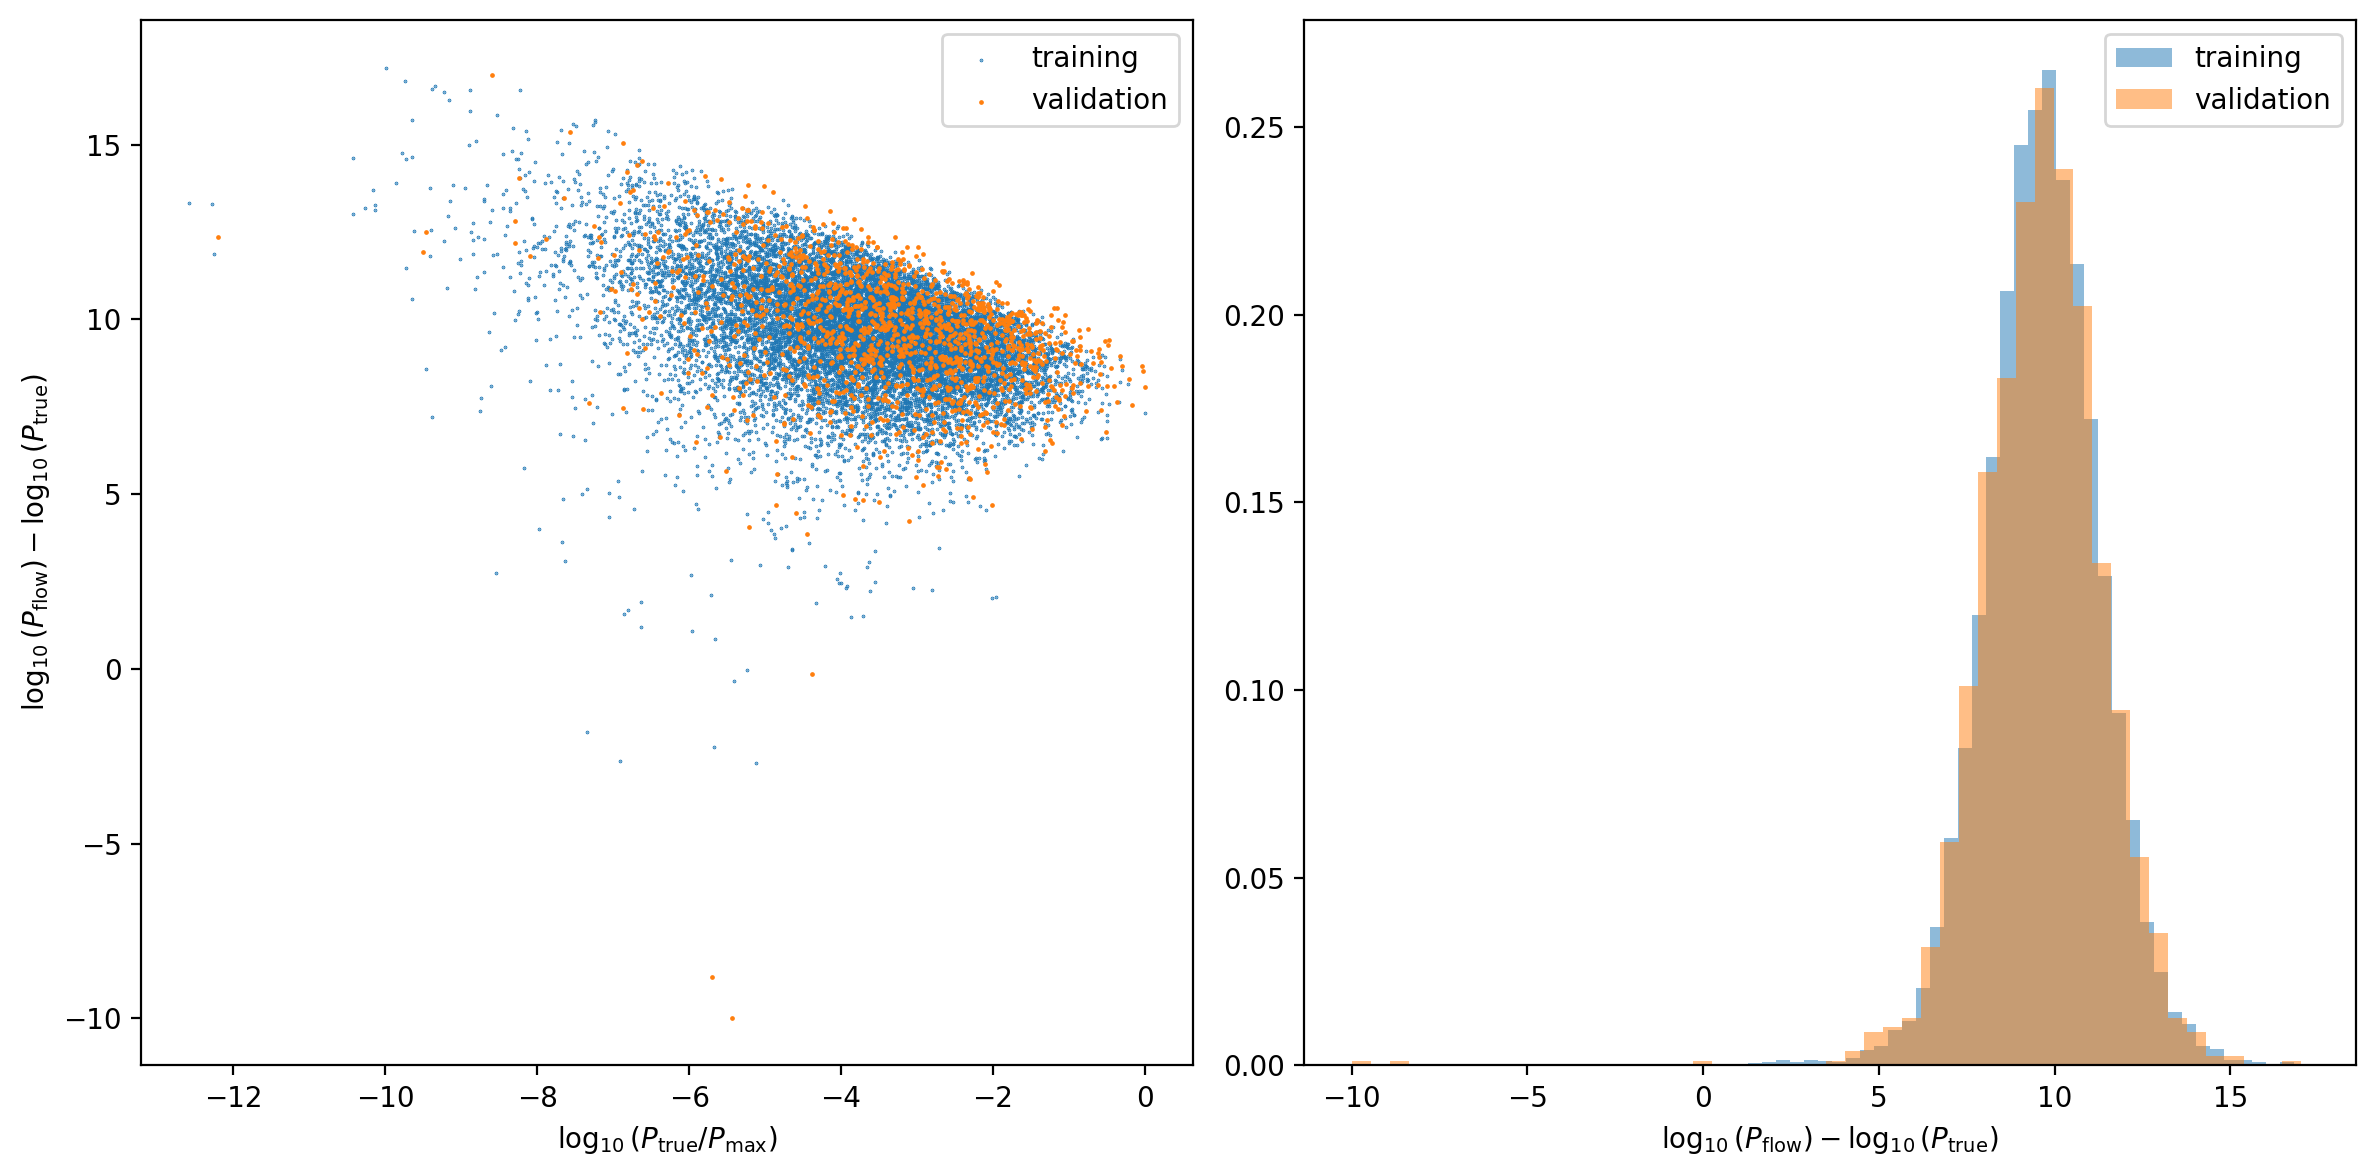

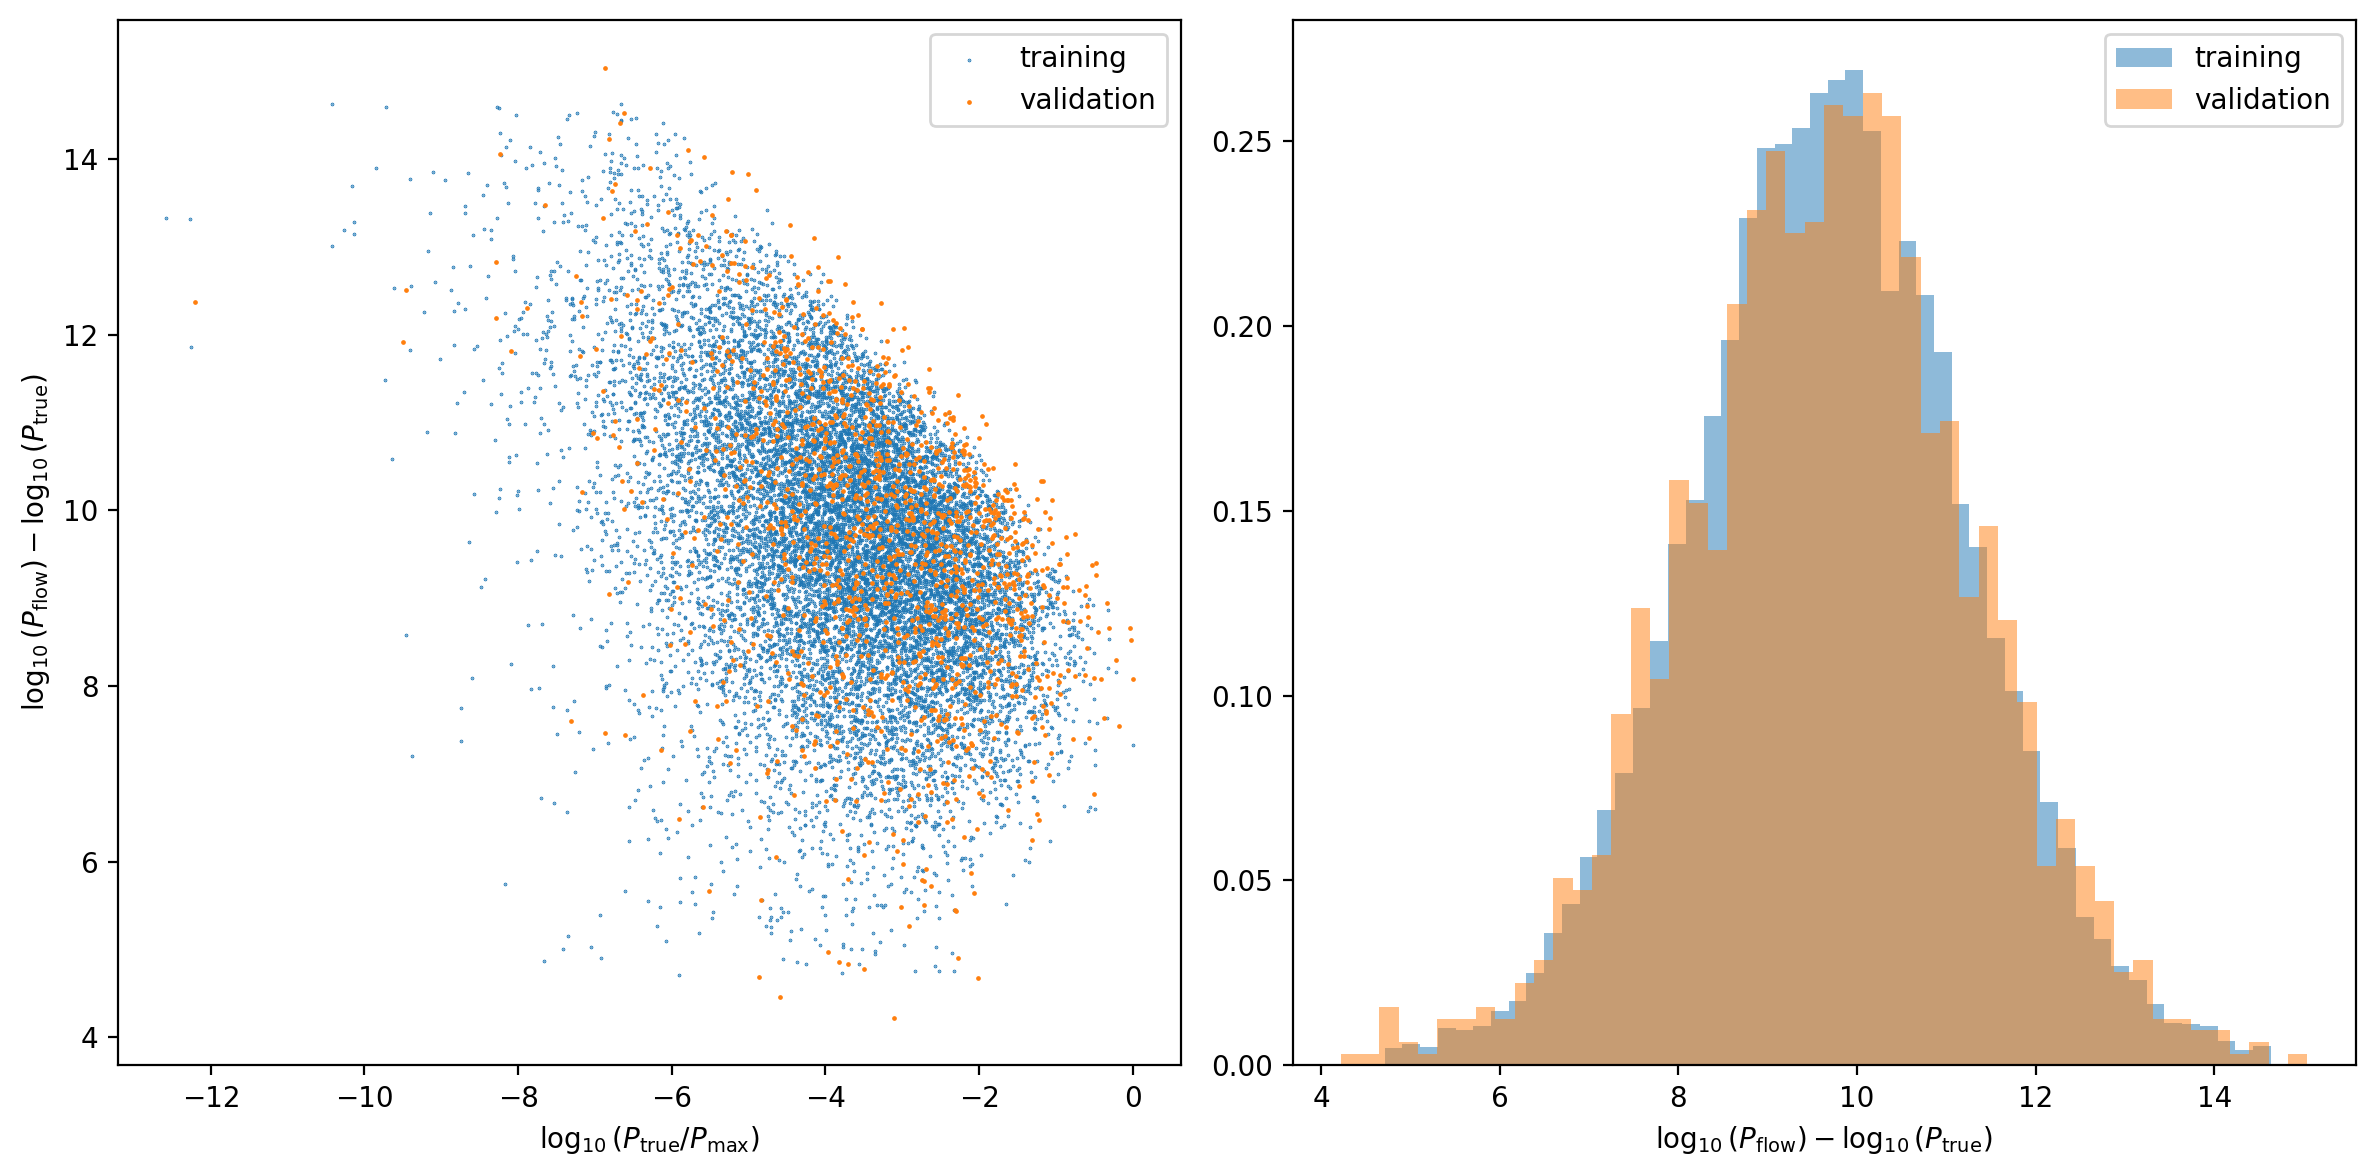

In [55]:
# Convert param names in samples to strings
stri = ['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'EFT_lambda', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'zrei', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']

param_names_all = [str(p) for p in stri]

# Params used in the flow
param_names = average_flow_exp.param_names
print(param_names)
# Get corresponding indices
param_indices = [param_names_all.index(p) for p in param_names]

# Select only the needed parameters from test samples
x = samples_exp.samples[average_flow_exp.test_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability
casted = average_flow_exp.cast(x)

validation_flow_log10_P = average_flow_exp.log_probability(casted).numpy() / np.log(10.) # VALIDATION FLOW
# Print the first few values of validation_flow_log10_P
print("First few values of validation_flow_log10_P:", validation_flow_log10_P[:3])

x_training = samples_exp.samples[average_flow_exp.training_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability for training samples
casted_training = average_flow_exp.cast(x_training)
training_flow_log10_P = average_flow_exp.log_probability(casted_training).numpy() / np.log(10.) # TRAINING FLOW

# Print the first few values of training_flow_log10_P
print("First few values of training_flow_log10_P:", training_flow_log10_P[:3])

#for i, name in enumerate(param_names):
 #   print(f"{i:2d}: {name:15s} --> values: {x[:3, i]}")

# Remove the loglikes from the samples:
loglike_max = np.max(samples_exp.loglikes)
validation_samples_log10_P = -(samples_exp.loglikes[average_flow_exp.test_idx] - loglike_max) / np.log(10.)
training_samples_log10_P = -(samples_exp.loglikes[average_flow_exp.training_idx] - loglike_max) / np.log(10.)    

#print("Training flow - true log10(P):", np.min(training_flow_log10_P - training_samples_log10_P), np.max(training_flow_log10_P - training_samples_log10_P))
#print("Validation flow - true log10(P):", np.min(validation_flow_log10_P - validation_samples_log10_P), np.max(validation_flow_log10_P - validation_samples_log10_P))

mean_training = np.mean(training_flow_log10_P - training_samples_log10_P)
mean_validation = np.mean(validation_flow_log10_P - validation_samples_log10_P)
print("Mean training difference:", mean_training)
print("Mean validation difference:", mean_validation)

# Difference between each point and the mean:
training_flow_diff = (training_flow_log10_P - training_samples_log10_P) - mean_training
validation_flow_diff = (validation_flow_log10_P - validation_samples_log10_P) - mean_validation
print("Training flow difference:", training_flow_diff[:3])
print("Validation flow difference:", validation_flow_diff[:3])

threshold_training = 3*np.std(training_flow_log10_P - training_samples_log10_P)
threshold_validation = 3*np.std(validation_flow_log10_P - validation_samples_log10_P) 
print("Threshold training:", threshold_training)
print("Threshold validation:", threshold_validation)
cont_train = 0
cont_val = 0
validation_samples_log10_P_del = []
validation_flow_log10_P_del = []
training_flow_log10_P_del = []
training_samples_log10_P_del = []

# I want to see which points are far from the mean and save another array with all points without the removed points:
for i, diff in enumerate(training_flow_diff):
    if np.abs(diff) > threshold_training:
        #print(f"Training point {i} is far from the mean: {diff}")
        cont_train += 1
        # create a new array with the points that are not far from the mean:
    else:
        training_samples_log10_P_del.append(training_samples_log10_P[i])
        training_flow_log10_P_del.append(training_flow_log10_P[i])
        #print(f"Training point {i} is not far from the mean: {diff}")

for i, diff in enumerate(validation_flow_diff):
    if np.abs(diff) > threshold_validation:
        #print(f"Validation point {i} is far from the mean: {diff}")
        cont_val += 1
        # create a new array with the points that are not far from the mean:
    else:
        validation_samples_log10_P_del.append(validation_samples_log10_P[i])
        validation_flow_log10_P_del.append(validation_flow_log10_P[i])
        #print(f"Validation point {i} is not far from the mean: {diff}")
        
print(f"Number of training points far from the mean: {cont_train}")
print(f"Number of validation points far from the mean: {cont_val}")

# Convert lists to numpy arrays:
training_samples_log10_P_del = np.array(training_samples_log10_P_del)
training_flow_log10_P_del = np.array(training_flow_log10_P_del)
validation_samples_log10_P_del = np.array(validation_samples_log10_P_del)
validation_flow_log10_P_del = np.array(validation_flow_log10_P_del)

# do the plot:
# with all the points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(training_samples_log10_P - np.amax(training_samples_log10_P), training_flow_log10_P - training_samples_log10_P, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P - np.amax(validation_samples_log10_P), validation_flow_log10_P - validation_samples_log10_P, s=0.5, label='validation')
ax1.legend()
#ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)

ax2.hist(training_flow_log10_P - training_samples_log10_P, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P - validation_samples_log10_P, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
#ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])

plt.tight_layout()
plt.show()


# Do the same thing but without the removed points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del - np.amax(training_samples_log10_P_del), training_flow_log10_P_del - training_samples_log10_P_del, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del - np.amax(validation_samples_log10_P_del), validation_flow_log10_P_del - validation_samples_log10_P_del, s=0.5, label='validation')
ax1.legend()
#ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)    
ax2.hist(training_flow_log10_P_del - training_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del - validation_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
#ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])  
plt.tight_layout()
plt.show()

In [56]:
# Compute the evidence:
training_filtered_indices_exp = [
    i for i, diff in enumerate(training_flow_diff)
    if np.abs(diff) <= threshold_training
]
ev_exp, eer_exp = average_flow_exp.evidence(indexes= training_filtered_indices_exp, 
                                               weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')

EXP: log(Z) = -16211.303217607658 +- 2.6935446700353367


In [57]:
# COS

['logA', 'ns', 'ombh2', 'omch2', 'tau', 'm', 'H0', 'omegam', 'sigma8']
First few values of validation_flow_log10_P: [16.920454 16.196896 17.451637]
First few values of training_flow_log10_P: [18.708057 16.672842 16.195026]
Mean training difference: 10.129734229247784
Mean validation difference: 10.08131974784878
Training flow difference: [-0.57617021 -3.90428026 -0.53077242]
Validation flow difference: [-2.12122947 -0.52087813 -0.49779561]
Threshold training: 1.5737703907088694
Threshold validation: 1.6047523080646693
Number of training points far from the mean: 3794
Number of validation points far from the mean: 404


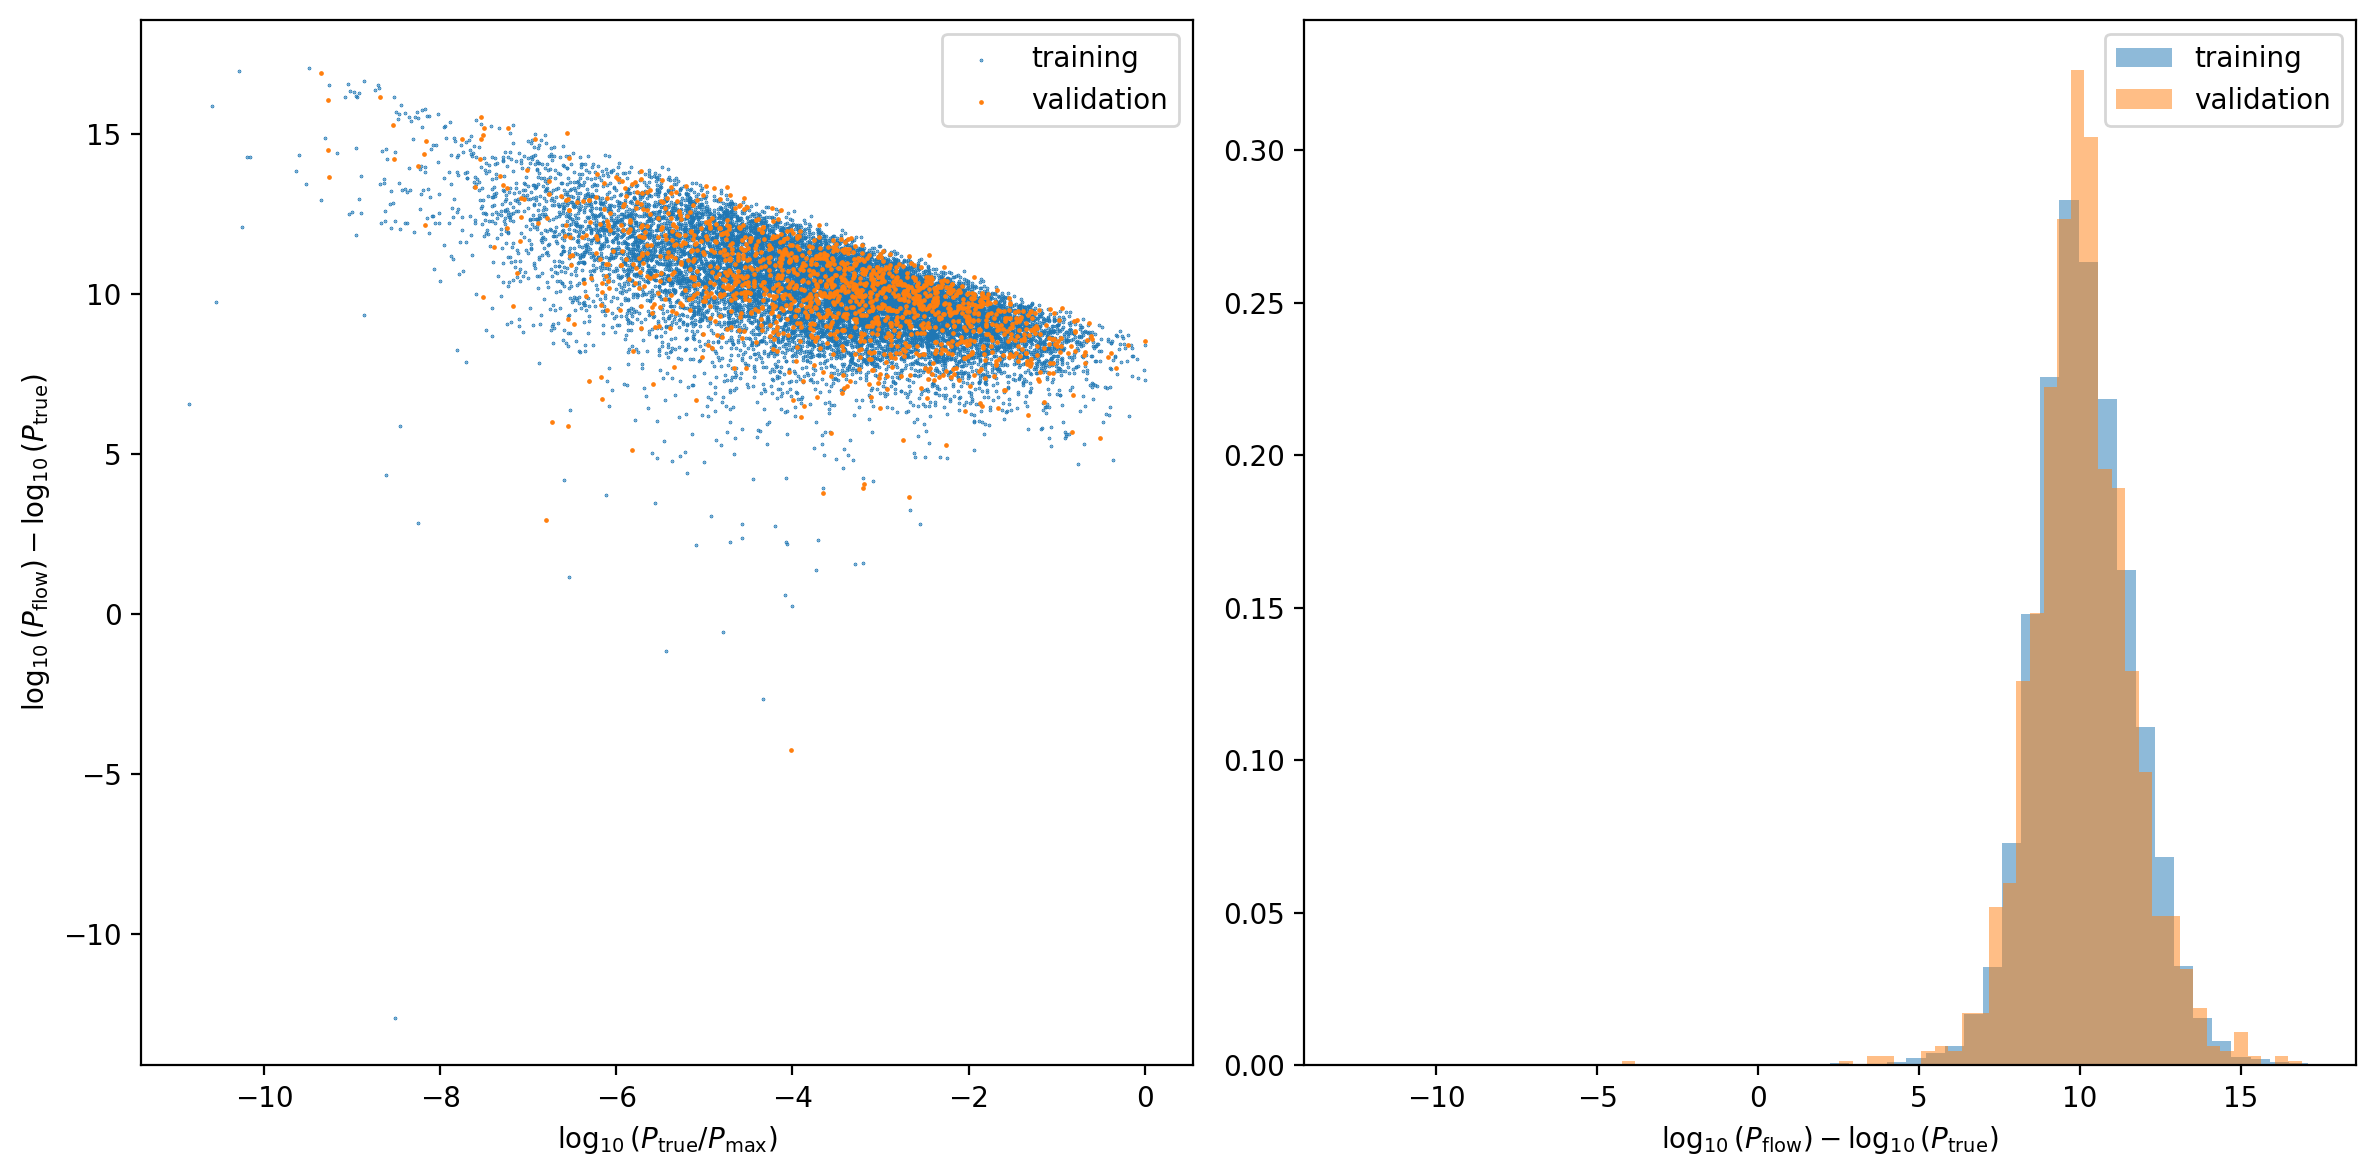

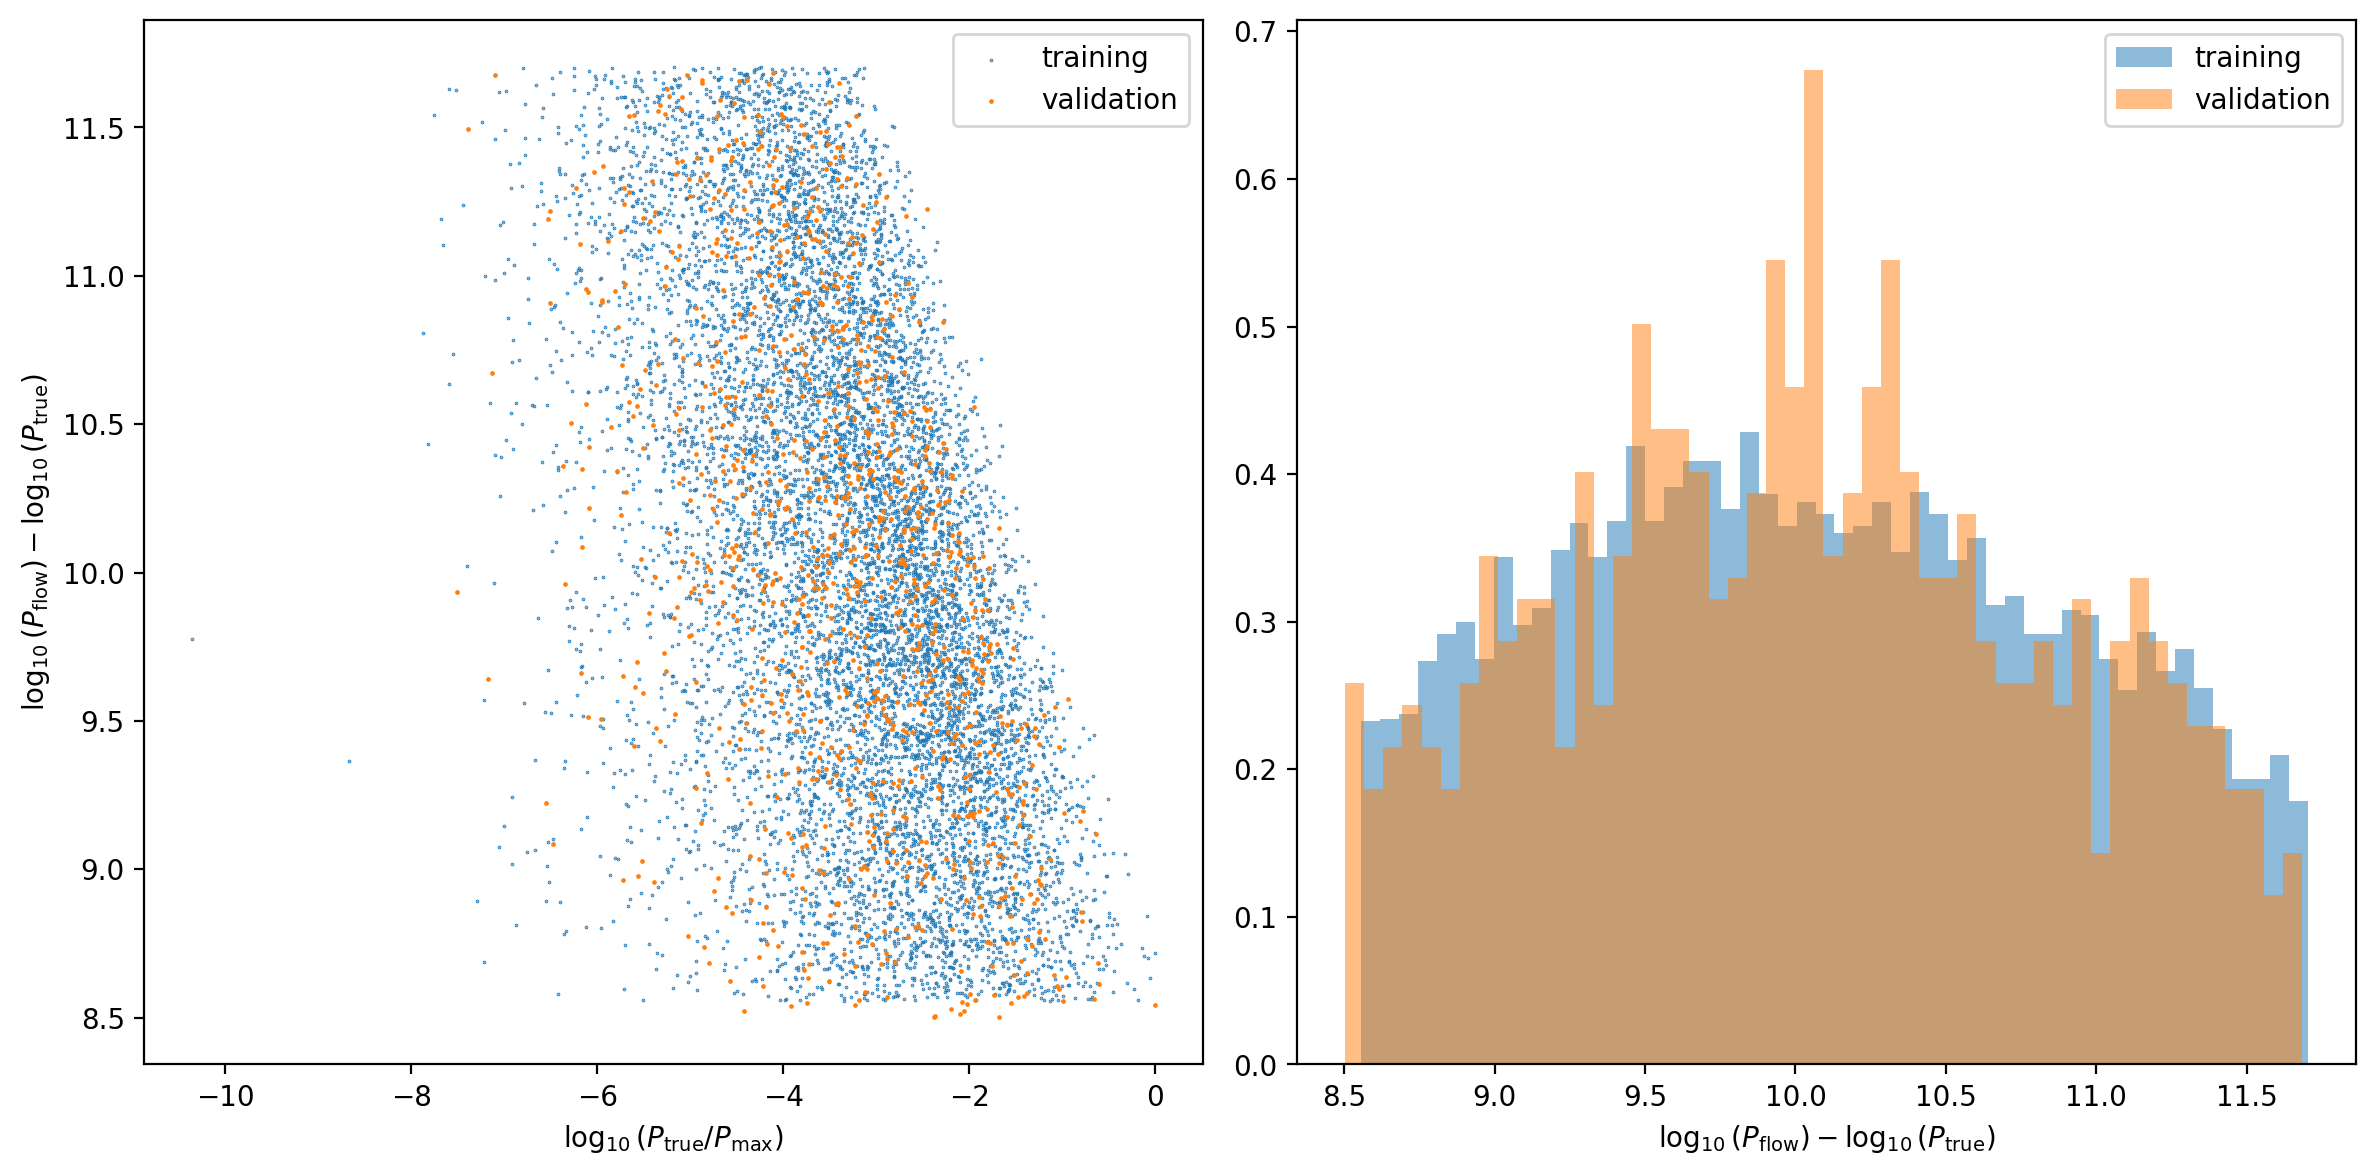

In [58]:
# Convert param names in samples to strings
stri = ['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'V0', 'm', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'zrei', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']
param_names_all = [str(p) for p in stri]

# Params used in the flow
param_names = average_flow_cos.param_names
print(param_names)
# Get corresponding indices
param_indices = [param_names_all.index(p) for p in param_names]

# Select only the needed parameters from test samples
x = samples_cos.samples[average_flow_cos.test_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability
casted = average_flow_cos.cast(x)

validation_flow_log10_P = average_flow_cos.log_probability(casted).numpy() / np.log(10.) # VALIDATION FLOW
# Print the first few values of validation_flow_log10_P
print("First few values of validation_flow_log10_P:", validation_flow_log10_P[:3])

x_training = samples_cos.samples[average_flow_cos.training_idx][:, param_indices].astype(np.float32)

# Cast and compute log-probability for training samples
casted_training = average_flow_cos.cast(x_training)
training_flow_log10_P = average_flow_cos.log_probability(casted_training).numpy() / np.log(10.) # TRAINING FLOW

# Print the first few values of training_flow_log10_P
print("First few values of training_flow_log10_P:", training_flow_log10_P[:3])

#for i, name in enumerate(param_names):
 #   print(f"{i:2d}: {name:15s} --> values: {x[:3, i]}")

# Remove the loglikes from the samples:
loglike_max = np.max(samples_cos.loglikes)
validation_samples_log10_P = -(samples_cos.loglikes[average_flow_cos.test_idx] - loglike_max) / np.log(10.)
training_samples_log10_P = -(samples_cos.loglikes[average_flow_cos.training_idx] - loglike_max) / np.log(10.)    

#print("Training flow - true log10(P):", np.min(training_flow_log10_P - training_samples_log10_P), np.max(training_flow_log10_P - training_samples_log10_P))
#print("Validation flow - true log10(P):", np.min(validation_flow_log10_P - validation_samples_log10_P), np.max(validation_flow_log10_P - validation_samples_log10_P))

mean_training = np.mean(training_flow_log10_P - training_samples_log10_P)
mean_validation = np.mean(validation_flow_log10_P - validation_samples_log10_P)
print("Mean training difference:", mean_training)
print("Mean validation difference:", mean_validation)

# Difference between each point and the mean:
training_flow_diff = (training_flow_log10_P - training_samples_log10_P) - mean_training
validation_flow_diff = (validation_flow_log10_P - validation_samples_log10_P) - mean_validation
print("Training flow difference:", training_flow_diff[:3])
print("Validation flow difference:", validation_flow_diff[:3])

threshold_training = np.std(training_flow_log10_P - training_samples_log10_P)
threshold_validation = np.std(validation_flow_log10_P - validation_samples_log10_P) 
print("Threshold training:", threshold_training)
print("Threshold validation:", threshold_validation)
cont_train = 0
cont_val = 0
validation_samples_log10_P_del = []
validation_flow_log10_P_del = []
training_flow_log10_P_del = []
training_samples_log10_P_del = []

# I want to see which points are far from the mean and save another array with all points without the removed points:
for i, diff in enumerate(training_flow_diff):
    if np.abs(diff) > threshold_training:
        #print(f"Training point {i} is far from the mean: {diff}")
        cont_train += 1
        # create a new array with the points that are not far from the mean:
    else:
        training_samples_log10_P_del.append(training_samples_log10_P[i])
        training_flow_log10_P_del.append(training_flow_log10_P[i])
        #print(f"Training point {i} is not far from the mean: {diff}")

for i, diff in enumerate(validation_flow_diff):
    if np.abs(diff) > threshold_validation:
        #print(f"Validation point {i} is far from the mean: {diff}")
        cont_val += 1
        # create a new array with the points that are not far from the mean:
    else:
        validation_samples_log10_P_del.append(validation_samples_log10_P[i])
        validation_flow_log10_P_del.append(validation_flow_log10_P[i])
        #print(f"Validation point {i} is not far from the mean: {diff}")
        
print(f"Number of training points far from the mean: {cont_train}")
print(f"Number of validation points far from the mean: {cont_val}")

# Convert lists to numpy arrays:
training_samples_log10_P_del = np.array(training_samples_log10_P_del)
training_flow_log10_P_del = np.array(training_flow_log10_P_del)
validation_samples_log10_P_del = np.array(validation_samples_log10_P_del)
validation_flow_log10_P_del = np.array(validation_flow_log10_P_del)

# do the plot:
# with all the points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(training_samples_log10_P - np.amax(training_samples_log10_P), training_flow_log10_P - training_samples_log10_P, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P - np.amax(validation_samples_log10_P), validation_flow_log10_P - validation_samples_log10_P, s=0.5, label='validation')
ax1.legend()
#ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)

ax2.hist(training_flow_log10_P - training_samples_log10_P, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P - validation_samples_log10_P, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
#ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])

plt.tight_layout()
plt.show()


# Do the same thing but without the removed points:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(training_samples_log10_P_del - np.amax(training_samples_log10_P_del), training_flow_log10_P_del - training_samples_log10_P_del, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P_del - np.amax(validation_samples_log10_P_del), validation_flow_log10_P_del - validation_samples_log10_P_del, s=0.5, label='validation')
ax1.legend()
#ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax1.set_ylim(-1.0, 1.0)    
ax2.hist(training_flow_log10_P_del - training_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P_del - validation_samples_log10_P_del, bins=50, density=True, alpha=0.5, label='validation')
ax2.legend()
#ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
#ax2.set_xlim([-1.0, 1.0])  
plt.tight_layout()
plt.show()

In [59]:
# Compute the evidence:
training_filtered_indices_cos = [
    i for i, diff in enumerate(training_flow_diff)
    if np.abs(diff) <= threshold_training
]
ev_cos, eer_cos = average_flow_cos.evidence(indexes= training_filtered_indices_cos, 
                                               weighted=True)
print(f'COS: log(Z) = {ev_cos} +- {eer_cos}')

COS: log(Z) = -16209.635321637146 +- 2.673399570326702


In [60]:
# Compare evidence:

#without weights:
ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(weighted=False)
print(f'LCDM: log(Z) (no weights) = {ev_lcdm} +- {eer_lcdm}')    

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(weighted=False)
print(f'W0WA: log(Z) (no weights) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = average_flow_exp.evidence(weighted=False)
print(f'EXP: log(Z) (no weights) = {ev_exp} +- {eer_exp}')

ev_cos, eer_cos = average_flow_cos.evidence(weighted=False)
print(f'COS: log(Z) (no weights) = {ev_cos} +- {eer_cos}')

# with weights:
ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) (yes weights) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) (yes weights) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = average_flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) (yes weights) = {ev_exp} +- {eer_exp}')

ev_cos, eer_cos = average_flow_cos.evidence(weighted=True)
print(f'COS: log(Z) (yes weights) = {ev_cos} +- {eer_cos}')

# without bad points and without weights:
ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(weighted=False, 
                                               indexes= training_filtered_indices_lcdm)
print(f'LCDM (filtered and no weights): log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(weighted=False,
                                                indexes= training_filtered_indices_w0wa)
print(f'W0WA (filtered and no weights): log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = average_flow_exp.evidence(weighted=False,
                                            indexes= training_filtered_indices_exp)
print(f'EXP (filtered and no weights): log(Z) = {ev_exp} +- {eer_exp}')

ev_cos, eer_cos = average_flow_cos.evidence(weighted=False,
                                            indexes= training_filtered_indices_cos)
print(f'COS (filtered and no weights): log(Z) = {ev_cos} +- {eer_cos}')

# without bad points:
ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(indexes= training_filtered_indices_lcdm, 
                                               weighted=True)
print(f'LCDM (filtered and yes weights): log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(indexes= training_filtered_indices_w0wa,
                                               weighted=True)
print(f'W0WA (filtered and yes weights): log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = average_flow_exp.evidence(indexes= training_filtered_indices_exp,
                                               weighted=True)
print(f'EXP (filtered and yes weights): log(Z) = {ev_exp} +- {eer_exp}')

ev_cos, eer_cos = average_flow_cos.evidence(indexes= training_filtered_indices_cos,
                                               weighted=True)
print(f'COS (filtered and yes weights): log(Z) = {ev_cos} +- {eer_cos}')

LCDM: log(Z) (no weights) = -16218.1513671875 +- 3.9251749515533447
W0WA: log(Z) (no weights) = -16205.6640625 +- 3.8346190452575684
EXP: log(Z) (no weights) = -16213.01171875 +- 3.835202932357788
COS: log(Z) (no weights) = -16212.123046875 +- 3.626560688018799
LCDM: log(Z) (yes weights) = -16216.390234230823 +- 2.4276781723581666
W0WA: log(Z) (yes weights) = -16203.011337747883 +- 2.063705942154699
EXP: log(Z) (yes weights) = -16211.291839601028 +- 2.7205946616976906
COS: log(Z) (yes weights) = -16209.611689087758 +- 2.5729144385426017
LCDM (filtered and no weights): log(Z) = -16218.1376953125 +- 3.922757387161255
W0WA (filtered and no weights): log(Z) = -16205.6767578125 +- 3.88106632232666
EXP (filtered and no weights): log(Z) = -16213.0849609375 +- 3.8117258548736572
COS (filtered and no weights): log(Z) = -16212.1962890625 +- 3.6957969665527344
LCDM (filtered and yes weights): log(Z) = -16216.428932779596 +- 2.4127067312654806
W0WA (filtered and yes weights): log(Z) = -16203.02400

# Explanation of the code
### To plot points:

validation points: points that we use to check how well the trained flow generalizes
training points: points use to train the normalizing flow. During the training the flow tries to learn P_flow that approximate P_true (true posterior)

REMEMBER: the true posterior is the posterior that Cobaya used (I do not choose the posterior, Cobaya build it). Cobaya build the posterior using the likelihood.